# Imports and paths

In [2]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ROOT_DIR = Path.cwd()
OUTPUT_DIR = ROOT_DIR / "outputs"

TRADES_PATH = (
    OUTPUT_DIR
    / "trades_with_previous_completed.parquet"
)

ROSTER_PATH = (
    OUTPUT_DIR
    / "trader_roster_non_pii.parquet"
)

# Load and validate required columns

In [4]:
trades = pd.read_parquet(TRADES_PATH)
trader_roster = pd.read_parquet(ROSTER_PATH)

print("Trades shape:", trades.shape)
print("Roster shape:", trader_roster.shape)

display(trades.head())
display(trader_roster.head())

Trades shape: (46520, 41)
Roster shape: (15874, 3)


,source_row_number,account_id,instrument,lot_size,close_trade_id,position_id,close_order_id,open_order_id,duration_sec,open_date_time,...,expected_net_profit,net_profit_difference,net_profit_reconciles,previous_completed_close_date_time,previous_completed_net_profit,previous_completed_amount,previous_completed_position_id,previous_completed_was_loss,previous_completed_was_win,reentry_gap_minutes
0,469,D#1589378,XAUUSD,100,7349874591903961172,7349874591885644259,7349874591964763954,7349874591964763848,69,2026-02-24 12:01:08+00:00,...,0.01,-8.673617e-18,True,NaT,NaN,NaN,<NA>,False,False,NaN
1,67,D#1589408,XAUUSD,100,7349874591903937304,7349874591885632215,7349874591964687230,7349874591964686681,372,2026-02-24 02:46:35+00:00,...,-187.92,2.842171e-14,True,NaT,NaN,NaN,<NA>,False,False,NaN
2,71,D#1589408,XAUUSD,100,7349874591903937451,7349874591885632342,7349874591964688132,7349874591964687814,189,2026-02-24 02:53:40+00:00,...,5.30,-8.881784e-16,True,2026-02-24 02:52:47+00:00,-187.92,0.43,7349874591885632215,True,False,0.883333
3,72,D#1589408,XAUUSD,100,7349874591903937523,7349874591885632391,7349874591964688391,7349874591964688227,63,2026-02-24 02:57:37+00:00,...,-72.00,0.000000e+00,True,2026-02-24 02:56:49+00:00,5.30,0.10,7349874591885632342,False,True,0.800000
4,729,D#1589410,XAUUSD,100,7349874591903989023,7349874591885657916,7349874591964835904,7349874591964834917,502,2026-02-25 00:13:04+00:00,...,45.40,0.000000e+00,True,NaT,NaN,NaN,<NA>,False,False,NaN


,campaign_id,campaign_date,account_id
0,33,2026-02-24,D#1614601
1,33,2026-02-24,D#1702708
2,33,2026-02-24,D#1702434
3,33,2026-02-24,D#1702729
4,33,2026-02-24,D#1702577


In [5]:
required_trade_columns = {
    "campaign_id",
    "account_id",
    "open_date_time",
    "close_date_time",
    "side",
    "amount",
    "net_profit",
}

missing_trade_columns = (
    required_trade_columns
    - set(trades.columns)
)

if missing_trade_columns:
    raise ValueError(
        "Missing required trade columns: "
        f"{sorted(missing_trade_columns)}"
    )

print("Required trade columns are present.")

Required trade columns are present.


# Baseline trade-idea construction

In [6]:
def assign_trade_ideas_baseline(
    trades: pd.DataFrame,
    maximum_gap_minutes: float = 3.0,
) -> pd.DataFrame:
    """Assigns baseline trade-idea identifiers.

    This reproduces the teammate's original grouping approach. Trades are
    grouped by account, campaign, instrument, and side. Within each group,
    a new idea begins when the next trade opens more than the specified gap
    after the latest close time tracked for the current idea.

    Args:
        trades: Standardized trade-level DataFrame.
        maximum_gap_minutes: Maximum gap allowed before starting a new idea.

    Returns:
        A copy of the trades with a baseline `idea_id` column.

    Raises:
        ValueError: If required columns are missing.
    """
    required_columns = {
        "account_id",
        "campaign_id",
        "instrument",
        "side",
        "open_date_time",
        "close_date_time",
    }

    missing_columns = (
        required_columns
        - set(trades.columns)
    )

    if missing_columns:
        raise ValueError(
            "Missing columns required for idea grouping: "
            f"{sorted(missing_columns)}"
        )

    group_columns = [
        "account_id",
        "campaign_id",
        "instrument",
        "side",
    ]

    sorted_trades = (
        trades
        .sort_values(
            group_columns + ["open_date_time"]
        )
        .copy()
    )

    idea_ids = pd.Series(
        index=sorted_trades.index,
        dtype="string",
    )

    idea_counter = 0

    for _, group in sorted_trades.groupby(
        group_columns,
        sort=False,
        dropna=False,
    ):
        group = group.sort_values(
            "open_date_time"
        )

        idea_counter += 1
        current_idea_id = (
            f"idea_{idea_counter}"
        )

        first_index = group.index[0]
        idea_ids.loc[first_index] = (
            current_idea_id
        )

        last_close_time = group.loc[
            first_index,
            "close_date_time",
        ]

        for row_index in group.index[1:]:
            open_time = group.loc[
                row_index,
                "open_date_time",
            ]

            if pd.isna(last_close_time):
                gap_minutes = np.inf
            else:
                gap_minutes = (
                    open_time - last_close_time
                ).total_seconds() / 60

            if gap_minutes > maximum_gap_minutes:
                idea_counter += 1
                current_idea_id = (
                    f"idea_{idea_counter}"
                )

            idea_ids.loc[row_index] = (
                current_idea_id
            )

            close_time = group.loc[
                row_index,
                "close_date_time",
            ]

            if pd.isna(last_close_time):
                last_close_time = close_time
            elif pd.notna(close_time):
                last_close_time = max(
                    last_close_time,
                    close_time,
                )

    sorted_trades["idea_id"] = idea_ids

    return (
        sorted_trades
        .sort_values(
            [
                "campaign_id",
                "account_id",
                "open_date_time",
            ]
        )
        .reset_index(drop=True)
    )

In [7]:
trades_with_ideas_baseline = (
    assign_trade_ideas_baseline(
        trades,
        maximum_gap_minutes=3.0,
    )
)

In [8]:
print(
    "Original trade rows:",
    len(trades),
)

print(
    "Rows after idea assignment:",
    len(trades_with_ideas_baseline),
)

print(
    "Number of baseline ideas:",
    trades_with_ideas_baseline[
        "idea_id"
    ].nunique(),
)

Original trade rows: 46520
Rows after idea assignment: 46520
Number of baseline ideas: 33379


## Confirm every trade received an idea ID

In [9]:
missing_idea_ids = (
    trades_with_ideas_baseline[
        "idea_id"
    ].isna().sum()
)

print(
    "Trades without idea ID:",
    missing_idea_ids,
)

Trades without idea ID: 0


## Confirm no idea spans different accounts, campaigns, instruments or sides

In [10]:
idea_group_validation = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .agg(
        account_count=(
            "account_id",
            "nunique",
        ),
        campaign_count=(
            "campaign_id",
            "nunique",
        ),
        instrument_count=(
            "instrument",
            "nunique",
        ),
        side_count=(
            "side",
            "nunique",
        ),
    )
)

invalid_idea_groups = idea_group_validation.loc[
    (idea_group_validation["account_count"] > 1)
    | (idea_group_validation["campaign_count"] > 1)
    | (idea_group_validation["instrument_count"] > 1)
    | (idea_group_validation["side_count"] > 1)
]

print(
    "Invalid idea groups:",
    len(invalid_idea_groups),
)

display(invalid_idea_groups.head())

Invalid idea groups: 0


,account_count,campaign_count,instrument_count,side_count
idea_id,,,,


## Build idea-size summary

In [11]:
idea_size_summary = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .size()
    .rename("number_of_trades")
    .reset_index()
)

display(
    idea_size_summary[
        "number_of_trades"
    ].describe()
)

count    33379.000000
mean         1.393691
std          1.059802
min          1.000000
25%          1.000000
50%          1.000000
75%          1.000000
max         30.000000
Name: number_of_trades, dtype: float64

In [12]:
idea_size_counts = (
    idea_size_summary[
        "number_of_trades"
    ]
    .value_counts()
    .sort_index()
    .rename_axis(
        "trades_per_idea"
    )
    .reset_index(
        name="number_of_ideas"
    )
)

display(
    idea_size_counts.head(20)
)

,trades_per_idea,number_of_ideas
0,1,25952
1,2,4757
2,3,1435
3,4,574
4,5,296
5,6,137
6,7,77
7,8,42
8,9,32
9,10,25


## Calculate multi-trade idea rates

In [ ]:
multi_trade_idea_count = (
    idea_size_summary[
        "number_of_trades"
    ].gt(1).sum()
)

multi_trade_idea_rate = (
    idea_size_summary[
        "number_of_trades"
    ].gt(1).mean()
)

trades_in_multi_trade_ideas = (
    idea_size_summary.loc[
        idea_size_summary[
            "number_of_trades"
        ] > 1,
        "number_of_trades",
    ].sum()
)

print(
    "Multi-trade ideas:",
    multi_trade_idea_count,
)

print(
    "Share of ideas with multiple trades:",
    f"{multi_trade_idea_rate:.2%}",
)

print(
    "Trades belonging to multi-trade ideas:",
    trades_in_multi_trade_ideas,
)

print(
    "Share of trades in multi-trade ideas:",
    f"{trades_in_multi_trade_ideas / len(trades):.2%}",
)

Multi-trade ideas: 7427
Share of ideas with multiple trades: 22.25%
Trades belonging to multi-trade ideas: 20568
Share of trades in multi-trade ideas: 44.21%


## Inspect the largest ideas

In [14]:
largest_ideas = (
    idea_size_summary
    .sort_values(
        "number_of_trades",
        ascending=False,
    )
    .head(20)
)

display(largest_ideas)

,idea_id,number_of_trades
25064,idea_32556,30
25063,idea_32555,29
8207,idea_17385,23
8702,idea_17830,21
28982,idea_6040,19
2472,idea_12222,18
19253,idea_27326,18
1067,idea_10959,17
28983,idea_6041,17
13287,idea_21957,17


In [15]:
example_idea_id = (
    largest_ideas.iloc[0]["idea_id"]
)

example_idea = (
    trades_with_ideas_baseline.loc[
        trades_with_ideas_baseline[
            "idea_id"
        ] == example_idea_id
    ]
    .sort_values("open_date_time")
)

display(
    example_idea[
        [
            "campaign_id",
            "account_id",
            "instrument",
            "side",
            "open_date_time",
            "close_date_time",
            "amount",
            "open_price",
            "close_price",
            "net_profit",
            "idea_id",
        ]
    ]
)

,campaign_id,account_id,instrument,side,open_date_time,close_date_time,amount,open_price,close_price,net_profit,idea_id
9423,40,D#1702739,XAUUSD,sell,2026-03-24 04:05:45+00:00,2026-03-24 04:06:54+00:00,0.20,4356.73,4353.54,61.20,idea_32556
9425,40,D#1702739,XAUUSD,sell,2026-03-24 04:07:50+00:00,2026-03-24 04:08:09+00:00,0.20,4352.25,4350.00,42.40,idea_32556
9427,40,D#1702739,XAUUSD,sell,2026-03-24 04:08:41+00:00,2026-03-24 04:09:08+00:00,0.20,4348.91,4351.33,-51.00,idea_32556
9429,40,D#1702739,XAUUSD,sell,2026-03-24 04:09:39+00:00,2026-03-24 04:14:18+00:00,0.20,4350.12,4350.48,-9.80,idea_32556
9431,40,D#1702739,XAUUSD,sell,2026-03-24 04:15:56+00:00,2026-03-24 04:16:28+00:00,0.11,4347.46,4345.38,21.44,idea_32556
9432,40,D#1702739,XAUUSD,sell,2026-03-24 04:16:37+00:00,2026-03-24 04:16:57+00:00,0.11,4347.71,4345.82,19.35,idea_32556
9434,40,D#1702739,XAUUSD,sell,2026-03-24 04:17:34+00:00,2026-03-24 04:18:27+00:00,0.20,4342.30,4340.66,30.20,idea_32556
9436,40,D#1702739,XAUUSD,sell,2026-03-24 04:19:03+00:00,2026-03-24 04:19:31+00:00,0.20,4340.23,4336.94,63.20,idea_32556
9437,40,D#1702739,XAUUSD,sell,2026-03-24 04:19:49+00:00,2026-03-24 04:20:32+00:00,0.20,4331.97,4329.24,52.00,idea_32556
9439,40,D#1702739,XAUUSD,sell,2026-03-24 04:20:52+00:00,2026-03-24 04:21:09+00:00,0.20,4331.75,4334.32,-54.00,idea_32556


## Add idea-level timing diagnostics

In [16]:
idea_timing_summary = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .agg(
        idea_start_time=(
            "open_date_time",
            "min",
        ),
        idea_end_time=(
            "close_date_time",
            "max",
        ),
        number_of_trades=(
            "idea_id",
            "size",
        ),
    )
    .reset_index()
)

idea_timing_summary[
    "idea_duration_minutes"
] = (
    idea_timing_summary["idea_end_time"]
    - idea_timing_summary["idea_start_time"]
).dt.total_seconds() / 60

In [17]:
display(
    idea_timing_summary[
        "idea_duration_minutes"
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

count    33379.000000
mean        33.235520
std         77.807406
min          0.000000
50%          8.983333
75%         27.491667
90%         79.283333
95%        148.251667
99%        398.529000
max       1374.933333
Name: idea_duration_minutes, dtype: float64

## Show longest ideas

In [18]:
display(
    idea_timing_summary
    .sort_values(
        "idea_duration_minutes",
        ascending=False,
    )
    .head(20)
)

,idea_id,idea_start_time,idea_end_time,number_of_trades,idea_duration_minutes
17137,idea_25421,2026-02-24 02:26:01+00:00,2026-02-25 01:20:57+00:00,2,1374.933333
28449,idea_5561,2026-05-26 03:06:35+00:00,2026-05-27 00:55:31+00:00,1,1308.933333
10370,idea_19331,2026-06-30 03:56:05+00:00,2026-07-01 00:58:01+00:00,2,1261.933333
7789,idea_17008,2026-05-07 01:10:27+00:00,2026-05-07 22:02:18+00:00,1,1251.850000
2648,idea_12381,2026-02-24 04:17:15+00:00,2026-02-25 01:01:27+00:00,1,1244.200000
28275,idea_5404,2026-03-17 04:55:34+00:00,2026-03-18 00:47:36+00:00,1,1192.033333
6392,idea_15751,2026-03-24 01:04:46+00:00,2026-03-24 20:25:01+00:00,1,1160.250000
27347,idea_457,2026-02-24 05:32:22+00:00,2026-02-25 00:43:48+00:00,1,1151.433333
14904,idea_23411,2026-02-24 06:42:15+00:00,2026-02-25 01:18:02+00:00,1,1115.783333
30103,idea_705,2026-04-14 07:05:52+00:00,2026-04-15 00:50:37+00:00,1,1064.750000


## Check the actual gaps inside each idea

In [19]:
idea_gap_check = (
    trades_with_ideas_baseline
    .sort_values(
        [
            "idea_id",
            "open_date_time",
        ]
    )
    .copy()
)

idea_gap_check[
    "previous_trade_close_time"
] = (
    idea_gap_check
    .groupby("idea_id")[
        "close_date_time"
    ]
    .shift(1)
)

idea_gap_check[
    "gap_from_previous_close_minutes"
] = (
    idea_gap_check["open_date_time"]
    - idea_gap_check[
        "previous_trade_close_time"
    ]
).dt.total_seconds() / 60

In [20]:
display(
    idea_gap_check[
        "gap_from_previous_close_minutes"
    ].describe()
)

count    13141.000000
mean         0.882681
std          4.886909
min       -538.300000
25%          0.250000
50%          0.650000
75%          1.450000
max          3.000000
Name: gap_from_previous_close_minutes, dtype: float64

## Build idea-level features

In [21]:
trades_with_ideas_baseline = (
    trades_with_ideas_baseline
    .sort_values(
        [
            "idea_id",
            "open_date_time",
            "close_date_time",
        ]
    )
    .copy()
)

trades_with_ideas_baseline[
    "trade_number_within_idea"
] = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .cumcount()
    + 1
)

In [22]:
display(
    trades_with_ideas_baseline[
        [
            "idea_id",
            "account_id",
            "campaign_id",
            "open_date_time",
            "amount",
            "trade_number_within_idea",
        ]
    ].head(20)
)

,idea_id,account_id,campaign_id,open_date_time,amount,trade_number_within_idea
0,idea_1,D#1589378,33,2026-02-24 12:01:08+00:00,0.01,1
10723,idea_10,D#1589378,42,2026-03-31 14:56:28+00:00,0.05,1
28969,idea_100,D#1589404,56,2026-05-29 14:25:08+00:00,0.48,1
36303,idea_1000,D#1591591,61,2026-06-16 01:04:34+00:00,0.50,1
7235,idea_10000,D#1702336,39,2026-03-20 10:57:54+00:00,0.08,1
7238,idea_10001,D#1702336,39,2026-03-20 13:46:51+00:00,0.08,1
7239,idea_10001,D#1702336,39,2026-03-20 13:51:16+00:00,0.08,2
7240,idea_10002,D#1702336,39,2026-03-20 14:00:47+00:00,0.08,1
11328,idea_10003,D#1702336,42,2026-03-31 08:33:46+00:00,0.05,1
11329,idea_10003,D#1702336,42,2026-03-31 08:42:26+00:00,0.50,2


# Create idea-level summary

In [23]:
idea_summary = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .agg(
        account_id=(
            "account_id",
            "first",
        ),
        campaign_id=(
            "campaign_id",
            "first",
        ),
        instrument=(
            "instrument",
            "first",
        ),
        side=(
            "side",
            "first",
        ),
        idea_start_time=(
            "open_date_time",
            "min",
        ),
        idea_end_time=(
            "close_date_time",
            "max",
        ),
        number_of_trades=(
            "idea_id",
            "size",
        ),
        total_amount=(
            "amount",
            "sum",
        ),
        mean_amount=(
            "amount",
            "mean",
        ),
        maximum_amount=(
            "amount",
            "max",
        ),
        minimum_amount=(
            "amount",
            "min",
        ),
        total_net_profit=(
            "net_profit",
            "sum",
        ),
    )
    .reset_index()
)

## Calculate duration

In [24]:
idea_summary["idea_duration_minutes"] = (
    idea_summary["idea_end_time"]
    - idea_summary["idea_start_time"]
).dt.total_seconds() / 60

## Add profitability

In [25]:
idea_summary["idea_profitable"] = (
    idea_summary["total_net_profit"] > 0
)

idea_summary["idea_losing"] = (
    idea_summary["total_net_profit"] < 0
)

idea_summary["idea_breakeven"] = (
    idea_summary["total_net_profit"] == 0
)

In [26]:
print("Idea rows:", len(idea_summary))
print("Unique ideas:", idea_summary["idea_id"].nunique())

display(idea_summary.head(10))

Idea rows: 33379
Unique ideas: 33379


,idea_id,account_id,campaign_id,instrument,side,idea_start_time,idea_end_time,number_of_trades,total_amount,mean_amount,maximum_amount,minimum_amount,total_net_profit,idea_duration_minutes,idea_profitable,idea_losing,idea_breakeven
0,idea_1,D#1589378,33,XAUUSD,sell,2026-02-24 12:01:08+00:00,2026-02-24 12:02:17+00:00,1,0.01,0.01,0.01,0.01,0.01,1.150000,True,False,False
1,idea_10,D#1589378,42,XAUUSD,buy,2026-03-31 14:56:28+00:00,2026-03-31 14:58:45+00:00,1,0.05,0.05,0.05,0.05,5.34,2.283333,True,False,False
2,idea_100,D#1589404,56,XAUUSD,sell,2026-05-29 14:25:08+00:00,2026-05-29 14:34:50+00:00,1,0.48,0.48,0.48,0.48,-249.12,9.700000,False,True,False
3,idea_1000,D#1591591,61,XAUUSD,sell,2026-06-16 01:04:34+00:00,2026-06-16 01:37:40+00:00,1,0.50,0.50,0.50,0.50,206.00,33.100000,True,False,False
4,idea_10000,D#1702336,39,XAUUSD,sell,2026-03-20 10:57:54+00:00,2026-03-20 11:05:41+00:00,1,0.08,0.08,0.08,0.08,-103.36,7.783333,False,True,False
5,idea_10001,D#1702336,39,XAUUSD,sell,2026-03-20 13:46:51+00:00,2026-03-20 13:51:52+00:00,2,0.16,0.08,0.08,0.08,148.00,5.016667,True,False,False
6,idea_10002,D#1702336,39,XAUUSD,sell,2026-03-20 14:00:47+00:00,2026-03-20 14:01:55+00:00,1,0.08,0.08,0.08,0.08,42.56,1.133333,True,False,False
7,idea_10003,D#1702336,42,XAUUSD,buy,2026-03-31 08:33:46+00:00,2026-03-31 08:52:22+00:00,5,2.05,0.41,0.50,0.05,-227.26,18.600000,False,True,False
8,idea_10004,D#1702336,42,XAUUSD,sell,2026-03-31 08:45:27+00:00,2026-03-31 08:45:34+00:00,1,0.50,0.50,0.50,0.50,-12.00,0.116667,False,True,False
9,idea_10005,D#1702336,42,XAUUSD,sell,2026-03-31 08:51:07+00:00,2026-03-31 08:51:16+00:00,1,0.50,0.50,0.50,0.50,-81.00,0.150000,False,True,False


# How size was built within each idea

In [ ]:
first_trade_features = (
    trades_with_ideas_baseline.loc[
        trades_with_ideas_baseline[
            "trade_number_within_idea"
        ] == 1,
        [
            "idea_id",
            "amount",
            "open_date_time",
        ],
    ]
    .rename(
        columns={
            "amount": "first_trade_amount",
            "open_date_time": "first_trade_open_time",
        }
    )
)

In [28]:
print(
    "First-trade rows:",
    len(first_trade_features),
)

print(
    "Unique first-trade ideas:",
    first_trade_features["idea_id"].nunique(),
)

First-trade rows: 33379
Unique first-trade ideas: 33379


## Merge first-trade information into idea_summary

In [29]:
idea_summary = idea_summary.merge(
    first_trade_features,
    on="idea_id",
    how="left",
    validate="one_to_one",
)

In [30]:
print(
    "Missing first-trade amounts:",
    idea_summary["first_trade_amount"].isna().sum(),
)

print(
    "Idea-summary rows after merge:",
    len(idea_summary),
)

Missing first-trade amounts: 0
Idea-summary rows after merge: 33379


## Mark single-trade and multi-trade ideas

In [31]:
idea_summary["multi_trade_idea"] = (
    idea_summary["number_of_trades"] > 1
)

In [32]:
display(
    idea_summary["multi_trade_idea"]
    .value_counts()
    .rename_axis("multi_trade_idea")
    .reset_index(name="number_of_ideas")
)

,multi_trade_idea,number_of_ideas
0,False,25952
1,True,7427


## Calculate entry_size_share

In [33]:
idea_summary["entry_size_share"] = np.where(
    idea_summary["total_amount"] > 0,
    (
        idea_summary["first_trade_amount"]
        / idea_summary["total_amount"]
    ),
    np.nan,
)

In [34]:
display(
    idea_summary.loc[
        idea_summary["multi_trade_idea"],
        "entry_size_share",
    ].describe(
        percentiles=[
            0.10,
            0.25,
            0.50,
            0.75,
            0.90,
        ]
    )
)

count    7427.000000
mean        0.382659
std         0.160366
min         0.002433
10%         0.142857
25%         0.250000
50%         0.454545
75%         0.500000
90%         0.500000
max         0.980392
Name: entry_size_share, dtype: float64

## Find when the largest trade appeared

In [35]:
maximum_amount_rows = (
    trades_with_ideas_baseline
    .sort_values(
        [
            "idea_id",
            "open_date_time",
            "close_date_time",
        ]
    )
    .loc[
        lambda df: (
            df["amount"]
            == df.groupby("idea_id")["amount"]
            .transform("max")
        )
    ]
    .drop_duplicates(
        subset=["idea_id"],
        keep="first",
    )
    [
        [
            "idea_id",
            "open_date_time",
            "trade_number_within_idea",
        ]
    ]
    .rename(
        columns={
            "open_date_time": "peak_trade_open_time",
            "trade_number_within_idea": "peak_trade_number",
        }
    )
)

In [36]:
print(
    "Peak-size rows:",
    len(maximum_amount_rows),
)

print(
    "Unique peak-size ideas:",
    maximum_amount_rows["idea_id"].nunique(),
)

Peak-size rows: 33379
Unique peak-size ideas: 33379


In [37]:
idea_summary = idea_summary.merge(
    maximum_amount_rows,
    on="idea_id",
    how="left",
    validate="one_to_one",
)

## Calculate time to peak trade size

In [38]:
idea_summary["minutes_to_peak_trade_size"] = (
    idea_summary["peak_trade_open_time"]
    - idea_summary["idea_start_time"]
).dt.total_seconds() / 60

In [39]:
idea_summary["peak_size_timing_ratio"] = np.where(
    idea_summary["idea_duration_minutes"] > 0,
    (
        idea_summary["minutes_to_peak_trade_size"]
        / idea_summary["idea_duration_minutes"]
    ),
    np.nan,
)

In [40]:
display(
    idea_summary.loc[
        idea_summary["multi_trade_idea"],
        [
            "minutes_to_peak_trade_size",
            "peak_size_timing_ratio",
        ],
    ].describe()
)

,minutes_to_peak_trade_size,peak_size_timing_ratio
count,7427.000000,7427.000000
mean,7.262825,0.150212
std,36.854457,0.283320
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,1.941667,0.139188
max,835.366667,0.999343


## Maximum to first amount ratio

In [41]:
idea_summary["maximum_to_first_amount_ratio"] = np.where(
    idea_summary["first_trade_amount"] > 0,
    (
        idea_summary["maximum_amount"]
        / idea_summary["first_trade_amount"]
    ),
    np.nan,
)

In [42]:
idea_summary["later_trade_larger_than_first"] = (
    idea_summary["maximum_to_first_amount_ratio"] > 1
)

In [43]:
display(
    idea_summary.loc[
        idea_summary["multi_trade_idea"],
        "maximum_to_first_amount_ratio",
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

count    7427.000000
mean        2.127116
std         4.795001
min         1.000000
50%         1.000000
75%         1.333333
90%         3.000000
95%         5.000000
99%        29.000000
max        60.000000
Name: maximum_to_first_amount_ratio, dtype: float64

## Measure each size transition

In [ ]:
trades_with_ideas_baseline = (
    trades_with_ideas_baseline
    .sort_values(
        [
            "idea_id",
            "trade_number_within_idea",
        ]
    )
    .copy()
)

trades_with_ideas_baseline[
    "previous_amount_within_idea"
] = (
    trades_with_ideas_baseline
    .groupby("idea_id")["amount"]
    .shift(1)
)

In [45]:
trades_with_ideas_baseline[
    "amount_increased_from_previous"
] = (
    trades_with_ideas_baseline["amount"]
    >
    trades_with_ideas_baseline[
        "previous_amount_within_idea"
    ]
)

## Summarize escalation per idea

In [46]:
idea_escalation_summary = (
    trades_with_ideas_baseline
    .groupby("idea_id")
    .agg(
        eligible_size_transitions=(
            "previous_amount_within_idea",
            lambda values: values.notna().sum(),
        ),
        size_increase_count=(
            "amount_increased_from_previous",
            "sum",
        ),
    )
    .reset_index()
)

In [47]:
idea_escalation_summary["size_increase_rate"] = np.where(
    idea_escalation_summary[
        "eligible_size_transitions"
    ] > 0,
    (
        idea_escalation_summary[
            "size_increase_count"
        ]
        / idea_escalation_summary[
            "eligible_size_transitions"
        ]
    ),
    np.nan,
)

In [48]:
idea_summary = idea_summary.merge(
    idea_escalation_summary,
    on="idea_id",
    how="left",
    validate="one_to_one",
)

# Validate all new idea features

In [49]:
idea_feature_validation = pd.Series({
    "idea_rows": len(idea_summary),
    "unique_idea_ids": (
        idea_summary["idea_id"].nunique()
    ),
    "missing_first_trade_amount": (
        idea_summary[
            "first_trade_amount"
        ].isna().sum()
    ),
    "missing_peak_trade_number": (
        idea_summary[
            "peak_trade_number"
        ].isna().sum()
    ),
    "entry_size_share_below_zero": (
        idea_summary[
            "entry_size_share"
        ].lt(0).sum()
    ),
    "entry_size_share_above_one": (
        idea_summary[
            "entry_size_share"
        ].gt(1).sum()
    ),
    "maximum_to_first_below_one": (
        idea_summary[
            "maximum_to_first_amount_ratio"
        ].lt(1).sum()
    ),
    "negative_minutes_to_peak": (
        idea_summary[
            "minutes_to_peak_trade_size"
        ].lt(0).sum()
    ),
    "peak_timing_ratio_above_one": (
        idea_summary[
            "peak_size_timing_ratio"
        ].gt(1).sum()
    ),
    "size_increase_rate_below_zero": (
        idea_summary[
            "size_increase_rate"
        ].lt(0).sum()
    ),
    "size_increase_rate_above_one": (
        idea_summary[
            "size_increase_rate"
        ].gt(1).sum()
    ),
})

display(
    idea_feature_validation.to_frame("value")
)

,value
idea_rows,33379
unique_idea_ids,33379
missing_first_trade_amount,0
missing_peak_trade_number,0
entry_size_share_below_zero,0
entry_size_share_above_one,0
maximum_to_first_below_one,0
negative_minutes_to_peak,0
peak_timing_ratio_above_one,0
size_increase_rate_below_zero,0


In [50]:
print(
    "Single-trade ideas with missing escalation rate:",
    idea_summary.loc[
        ~idea_summary["multi_trade_idea"],
        "size_increase_rate",
    ].isna().sum(),
)

print(
    "Multi-trade ideas with missing escalation rate:",
    idea_summary.loc[
        idea_summary["multi_trade_idea"],
        "size_increase_rate",
    ].isna().sum(),
)

Single-trade ideas with missing escalation rate: 25952
Multi-trade ideas with missing escalation rate: 0


In [51]:
idea_feature_columns = [
    "idea_id",
    "account_id",
    "campaign_id",
    "number_of_trades",
    "total_amount",
    "first_trade_amount",
    "entry_size_share",
    "maximum_amount",
    "maximum_to_first_amount_ratio",
    "peak_trade_number",
    "minutes_to_peak_trade_size",
    "size_increase_count",
    "eligible_size_transitions",
    "size_increase_rate",
    "total_net_profit",
]

display(
    idea_summary.loc[
        idea_summary["multi_trade_idea"],
        idea_feature_columns,
    ]
    .sort_values(
        [
            "number_of_trades",
            "maximum_to_first_amount_ratio",
        ],
        ascending=[False, False],
    )
    .head(20)
)

,idea_id,account_id,campaign_id,number_of_trades,total_amount,first_trade_amount,entry_size_share,maximum_amount,maximum_to_first_amount_ratio,peak_trade_number,minutes_to_peak_trade_size,size_increase_count,eligible_size_transitions,size_increase_rate,total_net_profit
25064,idea_32556,D#1702739,40,30,6.42,0.20,0.031153,0.30,1.500000,25,36.316667,2,29,0.068966,-22.91
25063,idea_32555,D#1702739,40,29,6.50,0.20,0.030769,0.30,1.500000,23,27.983333,1,28,0.035714,-172.90
8207,idea_17385,D#1702467,44,23,5.33,0.10,0.018762,0.32,3.200000,17,41.516667,3,22,0.136364,42.43
8702,idea_17830,D#1702476,63,21,3.95,0.30,0.075949,0.30,1.000000,1,0.000000,1,20,0.050000,188.26
28982,idea_6040,D#1670967,46,19,6.11,0.20,0.032733,0.45,2.250000,18,23.050000,6,18,0.333333,327.93
19253,idea_27326,D#1702656,61,18,6.67,0.17,0.025487,0.50,2.941176,10,6.200000,2,17,0.117647,-22.37
2472,idea_12222,D#1702375,40,18,1.60,0.05,0.031250,0.10,2.000000,5,22.583333,1,17,0.058824,9.96
9498,idea_18547,D#1702488,41,17,4.10,0.05,0.012195,0.30,6.000000,7,5.416667,2,16,0.125000,-192.82
28983,idea_6041,D#1670967,46,17,5.75,0.25,0.043478,0.45,1.800000,17,22.316667,5,16,0.312500,-422.67
13287,idea_21957,D#1702551,49,17,5.00,0.20,0.040000,0.30,1.500000,2,2.850000,1,16,0.062500,-236.40


# Visualization of idea feature

In [52]:
multi_trade_ideas = (
    idea_summary.loc[
        idea_summary["multi_trade_idea"]
    ]
    .copy()
)

print(
    "Multi-trade ideas:",
    len(multi_trade_ideas),
)

Multi-trade ideas: 7427


## Distribution of entry-size share

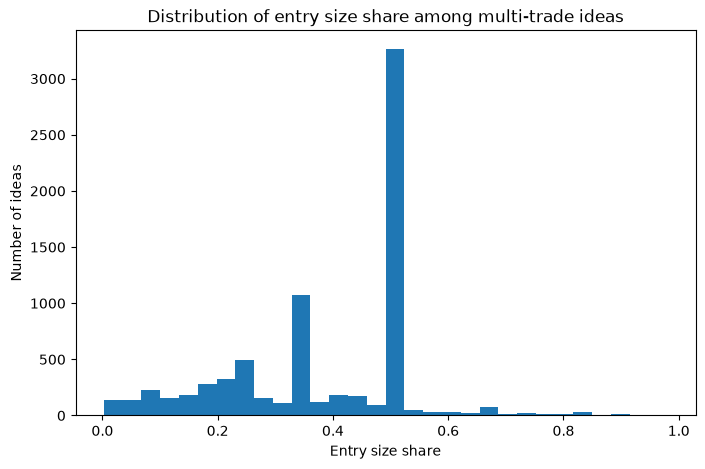

In [53]:
plt.figure(figsize=(8, 5))

plt.hist(
    multi_trade_ideas[
        "entry_size_share"
    ].dropna(),
    bins=30,
)

plt.xlabel("Entry size share")
plt.ylabel("Number of ideas")
plt.title(
    "Distribution of entry size share "
    "among multi-trade ideas"
)

plt.show()

## Distribution of maximum-to-first amount ratio

In [54]:
display(
    multi_trade_ideas[
        "maximum_to_first_amount_ratio"
    ].describe(
        percentiles=[
            0.50,
            0.75,
            0.90,
            0.95,
            0.99,
        ]
    )
)

count    7427.000000
mean        2.127116
std         4.795001
min         1.000000
50%         1.000000
75%         1.333333
90%         3.000000
95%         5.000000
99%        29.000000
max        60.000000
Name: maximum_to_first_amount_ratio, dtype: float64

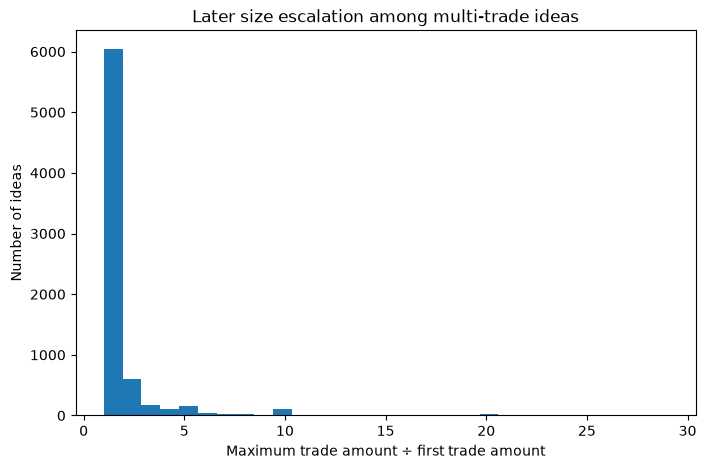

In [55]:
maximum_ratio_plot_limit = (
    multi_trade_ideas[
        "maximum_to_first_amount_ratio"
    ].quantile(0.99)
)

plt.figure(figsize=(8, 5))

plt.hist(
    multi_trade_ideas.loc[
        multi_trade_ideas[
            "maximum_to_first_amount_ratio"
        ] <= maximum_ratio_plot_limit,
        "maximum_to_first_amount_ratio",
    ].dropna(),
    bins=30,
)

plt.xlabel(
    "Maximum trade amount ÷ first trade amount"
)
plt.ylabel("Number of ideas")
plt.title(
    "Later size escalation among multi-trade ideas"
)

plt.show()

## When peak trade appeared

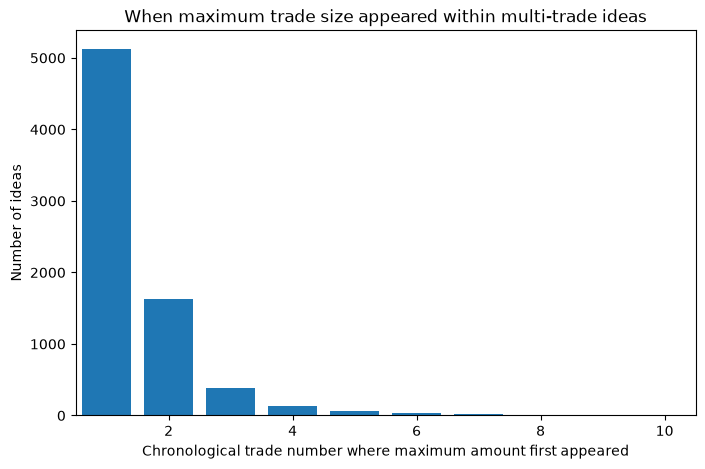

In [56]:
peak_trade_number_counts = (
    multi_trade_ideas[
        "peak_trade_number"
    ]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(8, 5))

plt.bar(
    peak_trade_number_counts.index,
    peak_trade_number_counts.values,
)

plt.xlabel(
    "Chronological trade number where "
    "maximum amount first appeared"
)
plt.ylabel("Number of ideas")
plt.title(
    "When maximum trade size appeared "
    "within multi-trade ideas"
)

plt.xlim(
    0.5,
    min(
        10.5,
        peak_trade_number_counts.index.max()
        + 0.5,
    ),
)

plt.show()

## Relationship between front-loading and idea profit

In [57]:
profit_lower = (
    multi_trade_ideas[
        "total_net_profit"
    ].quantile(0.01)
)

profit_upper = (
    multi_trade_ideas[
        "total_net_profit"
    ].quantile(0.99)
)

front_loading_profit_plot = (
    multi_trade_ideas.loc[
        multi_trade_ideas[
            "total_net_profit"
        ].between(
            profit_lower,
            profit_upper,
        )
    ]
)

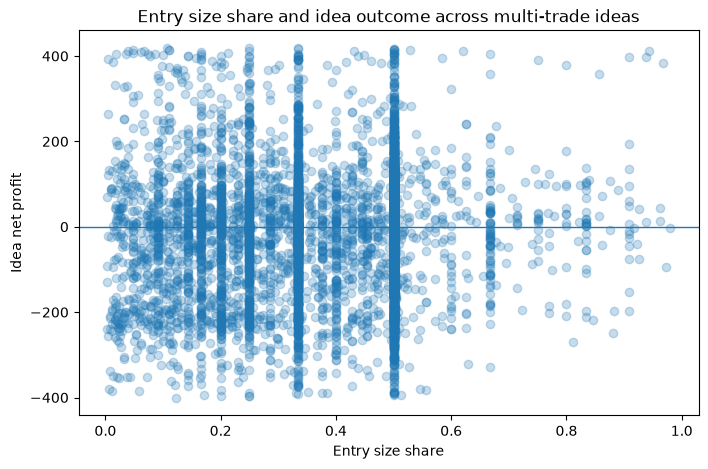

In [58]:
plt.figure(figsize=(8, 5))

plt.scatter(
    front_loading_profit_plot[
        "entry_size_share"
    ],
    front_loading_profit_plot[
        "total_net_profit"
    ],
    alpha=0.25,
)

plt.axhline(
    0,
    linewidth=1,
)

plt.xlabel("Entry size share")
plt.ylabel("Idea net profit")
plt.title(
    "Entry size share and idea outcome "
    "across multi-trade ideas"
)

plt.show()

## Compare profitable and losing ideas descriptively

In [59]:
multi_trade_ideas["idea_outcome"] = np.where(
    multi_trade_ideas[
        "total_net_profit"
    ] > 0,
    "Profitable idea",
    "Non-profitable idea",
)

In [60]:
idea_outcome_summary = (
    multi_trade_ideas
    .groupby("idea_outcome")
    .agg(
        number_of_ideas=(
            "idea_id",
            "size",
        ),
        median_entry_size_share=(
            "entry_size_share",
            "median",
        ),
        median_maximum_to_first_ratio=(
            "maximum_to_first_amount_ratio",
            "median",
        ),
        median_minutes_to_peak_size=(
            "minutes_to_peak_trade_size",
            "median",
        ),
        median_size_increase_rate=(
            "size_increase_rate",
            "median",
        ),
    )
    .reset_index()
)

display(idea_outcome_summary)

,idea_outcome,number_of_ideas,median_entry_size_share,median_maximum_to_first_ratio,median_minutes_to_peak_size,median_size_increase_rate
0,Non-profitable idea,4017,0.437500,1.0,0.0,0.0
1,Profitable idea,3410,0.479515,1.0,0.0,0.0


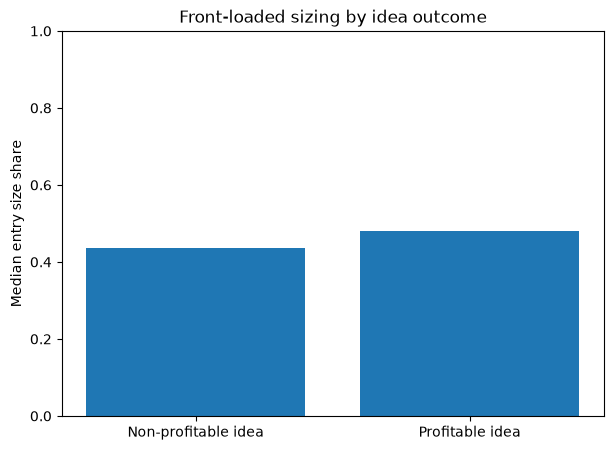

In [61]:
entry_share_by_outcome = (
    multi_trade_ideas
    .groupby("idea_outcome")[
        "entry_size_share"
    ]
    .median()
)

plt.figure(figsize=(7, 5))

plt.bar(
    entry_share_by_outcome.index,
    entry_share_by_outcome.values,
)

plt.ylabel("Median entry size share")
plt.title(
    "Front-loaded sizing by idea outcome"
)

plt.ylim(0, 1)

plt.show()

# Holding duration of losing position, entry sizing, size escalation, post-loss behaviour

## Unified behavioural analysis across three scenarios

Every behavioural feature is tested across:

1. Risk Takers — top 35% of the composite risk score;
2. Conservative traders — bottom 35%;
3. All Traders — the full account-campaign sample.

The Risk-Taker and Conservative analyses exclude the middle 30%, while the
All-Trader analysis includes every account-campaign.

In [62]:
from scipy import stats

## Risk score definition

In [63]:
def calculate_composite_risk_score(
    trades: pd.DataFrame,
) -> pd.DataFrame:
    """Calculates the shared account-campaign risk score.

    The score combines standardized average trade amount, lot-size
    coefficient of variation, and trade frequency.

    Args:
        trades: Standardized trade-level DataFrame.

    Returns:
        One row per account-campaign with risk features and segmentation.
    """
    risk_scores = (
        trades
        .groupby(
            [
                "account_id",
                "campaign_id",
            ]
        )
        .agg(
            avg_lot=("amount", "mean"),
            lot_std=("amount", "std"),
            n_trades=("amount", "size"),
        )
        .reset_index()
    )

    risk_scores["lot_std"] = (
        risk_scores["lot_std"]
        .fillna(0)
    )

    risk_scores["lot_cv"] = np.where(
        risk_scores["avg_lot"] > 0,
        (
            risk_scores["lot_std"]
            / risk_scores["avg_lot"]
        ),
        0,
    )

    risk_components = [
        "avg_lot",
        "lot_cv",
        "n_trades",
    ]

    for column in risk_components:
        standard_deviation = (
            risk_scores[column].std()
        )

        z_score_column = f"z_{column}"

        if standard_deviation == 0:
            risk_scores[z_score_column] = 0.0
        else:
            risk_scores[z_score_column] = (
                risk_scores[column]
                - risk_scores[column].mean()
            ) / standard_deviation

    risk_scores["composite_risk_score"] = (
        risk_scores["z_avg_lot"]
        + risk_scores["z_lot_cv"]
        + risk_scores["z_n_trades"]
    )

    lower_threshold = (
        risk_scores["composite_risk_score"]
        .quantile(0.35)
    )

    upper_threshold = (
        risk_scores["composite_risk_score"]
        .quantile(0.65)
    )

    risk_scores["risk_segment"] = np.select(
        [
            risk_scores["composite_risk_score"]
            <= lower_threshold,

            risk_scores["composite_risk_score"]
            >= upper_threshold,
        ],
        [
            "Conservative",
            "Risk Taker",
        ],
        default="Middle",
    )

    return risk_scores

In [64]:
risk_scores = calculate_composite_risk_score(
    trades
)

display(
    risk_scores["risk_segment"]
    .value_counts()
    .rename_axis("risk_segment")
    .reset_index(name="account_campaigns")
)

,risk_segment,account_campaigns
0,Conservative,2877
1,Risk Taker,2858
2,Middle,2430


## Define three datasets

In [65]:
risk_taker_keys = (
    risk_scores.loc[
        risk_scores["risk_segment"]
        == "Risk Taker",
        [
            "account_id",
            "campaign_id",
        ],
    ]
)

conservative_keys = (
    risk_scores.loc[
        risk_scores["risk_segment"]
        == "Conservative",
        [
            "account_id",
            "campaign_id",
        ],
    ]
)

## Add losing-trade duration

In [66]:
trades_with_duration = trades.copy()

trades_with_duration[
    "trade_duration_minutes"
] = (
    trades_with_duration["close_date_time"]
    - trades_with_duration["open_date_time"]
).dt.total_seconds() / 60

In [67]:
losing_trade_features = (
    trades_with_duration.loc[
        trades_with_duration["net_profit"] < 0
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ]
    )
    .agg(
        median_losing_trade_duration_minutes=(
            "trade_duration_minutes",
            "median",
        ),
        losing_trade_count=(
            "net_profit",
            "size",
        ),
    )
    .reset_index()
)

## Add losing-idea duration

In [68]:
losing_idea_features = (
    idea_summary.loc[
        idea_summary["total_net_profit"] < 0
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ]
    )
    .agg(
        median_losing_idea_duration_minutes=(
            "idea_duration_minutes",
            "median",
        ),
        losing_idea_count=(
            "idea_id",
            "size",
        ),
    )
    .reset_index()
)

## Create entry-size ratio

In [69]:
idea_features_with_average_lot = (
    idea_summary
    .merge(
        risk_scores[
            [
                "account_id",
                "campaign_id",
                "avg_lot",
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

In [70]:
idea_features_with_average_lot[
    "entry_size_ratio"
] = np.where(
    idea_features_with_average_lot[
        "avg_lot"
    ] > 0,
    (
        idea_features_with_average_lot[
            "first_trade_amount"
        ]
        / idea_features_with_average_lot[
            "avg_lot"
        ]
    ),
    np.nan,
)

In [71]:
multi_trade_idea_features = (
    idea_features_with_average_lot.loc[
        idea_features_with_average_lot[
            "multi_trade_idea"
        ]
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ]
    )
    .agg(
        median_entry_size_ratio=(
            "entry_size_ratio",
            "median",
        ),
        median_entry_size_share=(
            "entry_size_share",
            "median",
        ),
        median_minutes_to_peak_size=(
            "minutes_to_peak_trade_size",
            "median",
        ),
        median_size_increase_rate=(
            "size_increase_rate",
            "median",
        ),
        multi_trade_idea_count=(
            "idea_id",
            "size",
        ),
    )
    .reset_index()
)

## Build post-loss behaviour

In [72]:
required_post_loss_columns = {
    "previous_completed_net_profit",
    "previous_completed_amount",
    "reentry_gap_minutes",
}

missing_post_loss_columns = (
    required_post_loss_columns
    - set(trades.columns)
)

if missing_post_loss_columns:
    raise ValueError(
        "Missing post-loss columns: "
        f"{sorted(missing_post_loss_columns)}"
    )

In [73]:
post_loss_trades = trades.copy()

post_loss_trades["post_loss_entry"] = (
    post_loss_trades[
        "previous_completed_net_profit"
    ] < 0
)

post_loss_trades["fast_post_loss_reentry"] = (
    post_loss_trades["post_loss_entry"]
    & post_loss_trades[
        "reentry_gap_minutes"
    ].between(
        0,
        3,
        inclusive="both",
    )
)

post_loss_trades["post_loss_size_increase"] = (
    post_loss_trades["post_loss_entry"]
    & (
        post_loss_trades["amount"]
        >
        post_loss_trades[
            "previous_completed_amount"
        ]
    )
)

post_loss_trades["reactive_post_loss_entry"] = (
    post_loss_trades[
        "fast_post_loss_reentry"
    ]
    & post_loss_trades[
        "post_loss_size_increase"
    ]
)

In [74]:
post_loss_features = (
    post_loss_trades.loc[
        post_loss_trades["post_loss_entry"]
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ]
    )
    .agg(
        post_loss_entry_count=(
            "post_loss_entry",
            "size",
        ),
        median_post_loss_reentry_gap_minutes=(
            "reentry_gap_minutes",
            "median",
        ),
        fast_post_loss_reentry_count=(
            "fast_post_loss_reentry",
            "sum",
        ),
        post_loss_size_increase_count=(
            "post_loss_size_increase",
            "sum",
        ),
        reactive_post_loss_entry_count=(
            "reactive_post_loss_entry",
            "sum",
        ),
    )
    .reset_index()
)

In [75]:
post_loss_features[
    "fast_post_loss_reentry_rate"
] = (
    post_loss_features[
        "fast_post_loss_reentry_count"
    ]
    / post_loss_features[
        "post_loss_entry_count"
    ]
)

post_loss_features[
    "post_loss_size_increase_rate"
] = (
    post_loss_features[
        "post_loss_size_increase_count"
    ]
    / post_loss_features[
        "post_loss_entry_count"
    ]
)

post_loss_features[
    "reactive_post_loss_entry_rate"
] = (
    post_loss_features[
        "reactive_post_loss_entry_count"
    ]
    / post_loss_features[
        "post_loss_entry_count"
    ]
)

## Build one master account-campaign table

In [76]:
account_campaign_outcomes = (
    trades
    .groupby(
        [
            "account_id",
            "campaign_id",
        ]
    )
    .agg(
        total_net_profit=(
            "net_profit",
            "sum",
        ),
    )
    .reset_index()
)

account_campaign_outcomes["profitable"] = (
    account_campaign_outcomes[
        "total_net_profit"
    ] > 0
)

account_campaign_outcomes[
    "profitability_group"
] = np.where(
    account_campaign_outcomes["profitable"],
    "Profitable",
    "Unprofitable",
)

In [77]:
account_campaign_features = (
    risk_scores
    .merge(
        account_campaign_outcomes,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        multi_trade_idea_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        losing_trade_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        losing_idea_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        post_loss_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [78]:
print(
    "Account-campaign rows:",
    len(account_campaign_features),
)

print(
    "Unique account-campaigns:",
    account_campaign_features[
        [
            "account_id",
            "campaign_id",
        ]
    ].drop_duplicates().shape[0],
)

Account-campaign rows: 8165
Unique account-campaigns: 8165


## Define the three datasets

In [79]:
scenario_datasets = {
    "Risk Takers": (
        account_campaign_features.loc[
            account_campaign_features[
                "risk_segment"
            ] == "Risk Taker"
        ]
        .copy()
    ),
    "Conservative": (
        account_campaign_features.loc[
            account_campaign_features[
                "risk_segment"
            ] == "Conservative"
        ]
        .copy()
    ),
    "All Traders": (
        account_campaign_features.copy()
    ),
}

In [80]:
scenario_size_summary = pd.DataFrame(
    [
        {
            "scenario": scenario,
            "account_campaigns": len(data),
            "profitable": data["profitable"].sum(),
            "unprofitable": (
                ~data["profitable"]
            ).sum(),
        }
        for scenario, data
        in scenario_datasets.items()
    ]
)

display(scenario_size_summary)

,scenario,account_campaigns,profitable,unprofitable
0,Risk Takers,2858,925,1933
1,Conservative,2877,960,1917
2,All Traders,8165,2703,5462


## Features to test

In [81]:
behavioral_feature_definitions = {
    "median_entry_size_ratio": {
        "expected_profitable_direction": "higher",
        "category": "Entry sizing",
    },
    "median_entry_size_share": {
        "expected_profitable_direction": "higher",
        "category": "Entry sizing",
    },
    "median_minutes_to_peak_size": {
        "expected_profitable_direction": "lower",
        "category": "Entry sizing",
    },
    "median_size_increase_rate": {
        "expected_profitable_direction": "lower",
        "category": "Size escalation",
    },
    "median_losing_trade_duration_minutes": {
        "expected_profitable_direction": "lower",
        "category": "Eventual-loss duration",
    },
    "median_losing_idea_duration_minutes": {
        "expected_profitable_direction": "lower",
        "category": "Eventual-loss duration",
    },
    "median_post_loss_reentry_gap_minutes": {
        "expected_profitable_direction": "higher",
        "category": "Post-loss behaviour",
    },
    "fast_post_loss_reentry_rate": {
        "expected_profitable_direction": "lower",
        "category": "Post-loss behaviour",
    },
    "post_loss_size_increase_rate": {
        "expected_profitable_direction": "lower",
        "category": "Post-loss behaviour",
    },
    "reactive_post_loss_entry_rate": {
        "expected_profitable_direction": "lower",
        "category": "Post-loss behaviour",
    },
}

## Shared comparison function

In [82]:
def compare_profitability_groups(
    data: pd.DataFrame,
    feature: str,
) -> dict:
    """Compares a feature between profitable and unprofitable observations.

    Args:
        data: Account-campaign feature table for one scenario.
        feature: Numeric behavioural feature.

    Returns:
        Comparison statistics and rank-biserial effect size.
    """
    profitable_values = (
        data.loc[
            data["profitable"],
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    unprofitable_values = (
        data.loc[
            ~data["profitable"],
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    if (
        len(profitable_values) < 2
        or len(unprofitable_values) < 2
    ):
        return {
            "feature": feature,
            "profitable_n": len(profitable_values),
            "unprofitable_n": len(unprofitable_values),
            "profitable_median": np.nan,
            "unprofitable_median": np.nan,
            "median_difference": np.nan,
            "p_value": np.nan,
            "rank_biserial": np.nan,
        }

    u_statistic, p_value = stats.mannwhitneyu(
        profitable_values,
        unprofitable_values,
        alternative="two-sided",
    )

    rank_biserial = (
        2 * u_statistic
        / (
            len(profitable_values)
            * len(unprofitable_values)
        )
        - 1
    )

    profitable_median = (
        profitable_values.median()
    )

    unprofitable_median = (
        unprofitable_values.median()
    )

    return {
        "feature": feature,
        "profitable_n": len(profitable_values),
        "unprofitable_n": len(unprofitable_values),
        "profitable_median": profitable_median,
        "unprofitable_median": unprofitable_median,
        "median_difference": (
            profitable_median
            - unprofitable_median
        ),
        "p_value": p_value,
        "rank_biserial": rank_biserial,
    }

## Run every feature across all scenarios

In [83]:
comparison_results = []

for scenario, scenario_data in (
    scenario_datasets.items()
):
    for feature, definition in (
        behavioral_feature_definitions.items()
    ):
        result = compare_profitability_groups(
            data=scenario_data,
            feature=feature,
        )

        result["scenario"] = scenario
        result["category"] = (
            definition["category"]
        )
        result["expected_profitable_direction"] = (
            definition[
                "expected_profitable_direction"
            ]
        )

        comparison_results.append(result)

comparison_results = pd.DataFrame(
    comparison_results
)

In [84]:
number_of_features = len(
    behavioral_feature_definitions
)

comparison_results[
    "bonferroni_alpha"
] = 0.05 / number_of_features

comparison_results[
    "statistically_significant"
] = (
    comparison_results["p_value"]
    <
    comparison_results[
        "bonferroni_alpha"
    ]
)

In [85]:
comparison_results[
    "direction_supported"
] = np.where(
    comparison_results[
        "expected_profitable_direction"
    ] == "higher",
    (
        comparison_results[
            "profitable_median"
        ]
        >
        comparison_results[
            "unprofitable_median"
        ]
    ),
    (
        comparison_results[
            "profitable_median"
        ]
        <
        comparison_results[
            "unprofitable_median"
        ]
    ),
)

comparison_results[
    "supported_after_correction"
] = (
    comparison_results[
        "direction_supported"
    ]
    & comparison_results[
        "statistically_significant"
    ]
)

In [86]:
comparison_results_export = (
    comparison_results[
        [
            "scenario",
            "category",
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "rank_biserial",
            "p_value",
            "statistically_significant",
            "direction_supported",
            "supported_after_correction",
        ]
    ]
    .round(4)
)

comparison_results_export.to_csv(
    OUTPUT_DIR / "three_scenario_comparison_results.csv",
    index=False,
)

display(comparison_results_export)

print(
    "Saved to:",
    OUTPUT_DIR / "three_scenario_comparison_results.csv",
)

,scenario,category,feature,profitable_n,unprofitable_n,profitable_median,unprofitable_median,median_difference,rank_biserial,p_value,statistically_significant,direction_supported,supported_after_correction
0,Risk Takers,Entry sizing,median_entry_size_ratio,731,1390,0.9783,0.9041,0.0742,0.1057,0.0001,True,True,True
1,Risk Takers,Entry sizing,median_entry_size_share,731,1390,0.3845,0.3343,0.0501,0.0911,0.0005,True,True,True
2,Risk Takers,Entry sizing,median_minutes_to_peak_size,731,1390,0.0000,0.0833,-0.0833,-0.0484,0.0482,False,True,False
3,Risk Takers,Size escalation,median_size_increase_rate,731,1390,0.0000,0.1000,-0.1000,-0.0555,0.0236,False,True,False
4,Risk Takers,Eventual-loss duration,median_losing_trade_duration_minutes,735,1933,3.1667,3.5500,-0.3833,-0.0656,0.0088,False,True,False
5,Risk Takers,Eventual-loss duration,median_losing_idea_duration_minutes,610,1933,6.2708,7.3333,-1.0625,-0.0808,0.0026,True,True,True
6,Risk Takers,Post-loss behaviour,median_post_loss_reentry_gap_minutes,723,1586,1.0000,0.9000,0.1000,0.0364,0.1601,False,True,False
7,Risk Takers,Post-loss behaviour,fast_post_loss_reentry_rate,723,1586,0.8000,0.8333,-0.0333,-0.0258,0.2985,False,True,False
8,Risk Takers,Post-loss behaviour,post_loss_size_increase_rate,723,1586,0.2727,0.2500,0.0227,0.0203,0.4247,False,False,False
9,Risk Takers,Post-loss behaviour,reactive_post_loss_entry_rate,723,1586,0.0909,0.0488,0.0421,0.0306,0.2071,False,False,False


Saved to: /Users/charltonsiaw/Desktop/C22-veNTUre/outputs/three_scenario_comparison_results.csv


# Trading intensity and idea complexity

## Build account-campaign activity duration

In [87]:
account_campaign_activity = (
    trades
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        first_open_date_time=(
            "open_date_time",
            "min",
        ),
        last_close_date_time=(
            "close_date_time",
            "max",
        ),
        total_trades=(
            "account_id",
            "size",
        ),
    )
)

account_campaign_activity[
    "active_duration_hours"
] = (
    account_campaign_activity[
        "last_close_date_time"
    ]
    - account_campaign_activity[
        "first_open_date_time"
    ]
).dt.total_seconds() / 3600

In [88]:
display(
    account_campaign_activity[
        "active_duration_hours"
    ].describe()
)

print(
    "Zero-duration account-campaigns:",
    (
        account_campaign_activity[
            "active_duration_hours"
        ] <= 0
    ).sum(),
)

count    8165.000000
mean        4.323392
std         4.811970
min         0.000556
25%         0.536944
50%         2.348056
75%         6.844167
max        28.911667
Name: active_duration_hours, dtype: float64

Zero-duration account-campaigns: 0


In [89]:
account_campaign_activity.loc[
    account_campaign_activity[
        "active_duration_hours"
    ] <= 0,
    "active_duration_hours",
] = np.nan

## Build idea-complexity features

In [90]:
idea_complexity_features = (
    idea_summary
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        total_ideas=(
            "idea_id",
            "nunique",
        ),
        median_trades_per_idea=(
            "number_of_trades",
            "median",
        ),
        mean_trades_per_idea=(
            "number_of_trades",
            "mean",
        ),
        multi_trade_idea_count=(
            "multi_trade_idea",
            "sum",
        ),
    )
)

In [91]:
idea_complexity_features[
    "multi_trade_idea_rate"
] = (
    idea_complexity_features[
        "multi_trade_idea_count"
    ]
    / idea_complexity_features[
        "total_ideas"
    ]
)

In [92]:
display(
    idea_complexity_features[
        [
            "total_ideas",
            "median_trades_per_idea",
            "mean_trades_per_idea",
            "multi_trade_idea_count",
            "multi_trade_idea_rate",
        ]
    ].describe()
)

,total_ideas,median_trades_per_idea,mean_trades_per_idea,multi_trade_idea_count,multi_trade_idea_rate
count,8165.000000,8165.0,8165.0,8165.0,8165.0
mean,4.088059,1.308328,1.423658,0.909614,0.233355
std,4.342594,0.905102,0.892559,1.488865,0.318616
min,1.000000,1.0,1.0,0.0,0.0
25%,1.000000,1.0,1.0,0.0,0.0
50%,3.000000,1.0,1.0,0.0,0.0
75%,5.000000,1.0,1.5,1.0,0.4
max,64.000000,29.0,21.0,27.0,1.0


In [93]:
assert (
    idea_complexity_features[
        "multi_trade_idea_rate"
    ]
    .dropna()
    .between(0, 1)
    .all()
), "multi_trade_idea_rate must be between 0 and 1."

In [94]:
assert not idea_complexity_features.duplicated(
    [
        "account_id",
        "campaign_id",
    ]
).any(), (
    "idea_complexity_features contains duplicate "
    "account-campaign rows."
)

print(
    "Account-campaign rows:",
    len(idea_complexity_features),
)

Account-campaign rows: 8165


## Merge activity and idea-complexity features

In [95]:
activity_complexity_features = (
    account_campaign_activity
    .merge(
        idea_complexity_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

## Calculate trading intensity

In [96]:
activity_complexity_features[
    "trades_per_active_hour"
] = (
    activity_complexity_features[
        "total_trades"
    ]
    / activity_complexity_features[
        "active_duration_hours"
    ]
)

activity_complexity_features[
    "ideas_per_active_hour"
] = (
    activity_complexity_features[
        "total_ideas"
    ]
    / activity_complexity_features[
        "active_duration_hours"
    ]
)

In [97]:
intensity_columns = [
    "trades_per_active_hour",
    "ideas_per_active_hour",
]

activity_complexity_features[
    intensity_columns
] = (
    activity_complexity_features[
        intensity_columns
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
)

In [98]:
display(
    activity_complexity_features[
        [
            "active_duration_hours",
            "total_trades",
            "total_ideas",
            "median_trades_per_idea",
            "multi_trade_idea_rate",
            "trades_per_active_hour",
            "ideas_per_active_hour",
        ]
    ].describe()
)

,active_duration_hours,total_trades,total_ideas,median_trades_per_idea,multi_trade_idea_rate,trades_per_active_hour,ideas_per_active_hour
count,8165.000000,8165.0,8165.000000,8165.0,8165.0,8165.0,8165.000000
mean,4.323392,5.697489,4.088059,1.308328,0.233355,8.214311,6.446905
std,4.811970,6.787031,4.342594,0.905102,0.318616,40.798658,40.028558
min,0.000556,1.0,1.000000,1.0,0.0,0.045839,0.043638
25%,0.536944,2.0,1.000000,1.0,0.0,0.727126,0.610791
50%,2.348056,4.0,3.000000,1.0,0.0,1.8536,1.445899
75%,6.844167,7.0,5.000000,1.0,0.4,6.006674,4.251969
max,28.911667,152.0,64.000000,29.0,1.0,1800.0,1800.000000


## Validate the activity features

In [99]:
activity_validation = pd.DataFrame(
    {
        "feature": [
            "active_duration_hours",
            "total_trades",
            "total_ideas",
            "median_trades_per_idea",
            "multi_trade_idea_rate",
            "trades_per_active_hour",
            "ideas_per_active_hour",
        ],
        "missing_count": [
            activity_complexity_features[
                column
            ].isna().sum()
            for column in [
                "active_duration_hours",
                "total_trades",
                "total_ideas",
                "median_trades_per_idea",
                "multi_trade_idea_rate",
                "trades_per_active_hour",
                "ideas_per_active_hour",
            ]
        ],
    }
)

display(activity_validation)

,feature,missing_count
0,active_duration_hours,0
1,total_trades,0
2,total_ideas,0
3,median_trades_per_idea,0
4,multi_trade_idea_rate,0
5,trades_per_active_hour,0
6,ideas_per_active_hour,0


In [100]:
assert (
    activity_complexity_features[
        "total_trades"
    ] >= 1
).all(), "Every account-campaign should contain at least one trade."

assert (
    activity_complexity_features[
        "total_ideas"
    ] >= 1
).all(), "Every account-campaign should contain at least one idea."

assert (
    activity_complexity_features[
        "median_trades_per_idea"
    ] >= 1
).all(), "Median trades per idea cannot be below one."

assert (
    activity_complexity_features[
        "multi_trade_idea_rate"
    ].between(0, 1).all()
), "Multi-trade idea rate must be between zero and one."

## Merge with the All-Trader outcome table

In [101]:
activity_columns_to_merge = [
    "account_id",
    "campaign_id",
    "active_duration_hours",
    "total_trades",
    "total_ideas",
    "median_trades_per_idea",
    "mean_trades_per_idea",
    "multi_trade_idea_count",
    "multi_trade_idea_rate",
    "trades_per_active_hour",
    "ideas_per_active_hour",
]

In [102]:
new_feature_columns = [
    column
    for column in activity_columns_to_merge
    if column not in [
        "account_id",
        "campaign_id",
    ]
]

all_trader_features = (
    account_campaign_features
    .drop(
        columns=new_feature_columns,
        errors="ignore",
    )
    .merge(
        activity_complexity_features[
            activity_columns_to_merge
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [103]:
print(
    "All account-campaigns:",
    len(all_trader_features),
)

display(
    all_trader_features[
        "profitability_group"
    ].value_counts()
)

All account-campaigns: 8165


profitability_group
Unprofitable    5462
Profitable      2703
Name: count, dtype: int64

## Define four exploratory features

In [104]:
activity_feature_columns = [
    "median_trades_per_idea",
    "multi_trade_idea_rate",
    "trades_per_active_hour",
    "ideas_per_active_hour",
]

## Generate descriptive statistics

In [105]:
activity_group_summary = (
    all_trader_features
    .groupby(
        "profitability_group"
    )[activity_feature_columns]
    .agg(
        [
            "count",
            "median",
            "mean",
        ]
    )
)

display(
    activity_group_summary.round(4)
)

median_trades_per_idea                 \
                                     count median    mean   
profitability_group                                         
Profitable                            2703    1.0  1.2601   
Unprofitable                          5462    1.0  1.3322   

                    multi_trade_idea_rate                  \
                                    count  median    mean   
profitability_group                                         
Profitable                           2703  0.0833  0.2178   
Unprofitable                         5462     0.0   0.241   

                    trades_per_active_hour                  \
                                     count  median    mean   
profitability_group                                          
Profitable                            2703  1.3168  6.4161   
Unprofitable                          5462   2.279  9.1042   

                    ideas_per_active_hour                  
                                    count  median    mean  
profitability_group                                        
Profitable                           2703  1.0234  5.2126  
Unprofitable                         5462  1.7678  7.0577

## Check for extreme intensity values

In [106]:
display(
    all_trader_features[
        [
            "active_duration_hours",
            "trades_per_active_hour",
            "ideas_per_active_hour",
        ]
    ].describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
)

,active_duration_hours,trades_per_active_hour,ideas_per_active_hour
count,8165.000000,8165.0,8165.000000
mean,4.323392,8.214311,6.446905
std,4.811970,40.798658,40.028558
min,0.000556,0.045839,0.043638
1%,0.015278,0.115723,0.107330
5%,0.066167,0.2456,0.212548
25%,0.536944,0.727126,0.610791
50%,2.348056,1.8536,1.445899
75%,6.844167,6.006674,4.251969
95%,14.045889,29.008939,19.354839


In [107]:
display(
    all_trader_features[
        [
            "account_id",
            "campaign_id",
            "active_duration_hours",
            "total_trades",
            "total_ideas",
            "trades_per_active_hour",
            "ideas_per_active_hour",
        ]
    ]
    .sort_values(
        "trades_per_active_hour",
        ascending=False,
    )
    .head(20)
)

,account_id,campaign_id,active_duration_hours,total_trades,total_ideas,trades_per_active_hour,ideas_per_active_hour
3096,D#1702381,35,0.000556,1,1,1800.0,1800.000000
3745,D#1702433,45,0.000556,1,1,1800.0,1800.000000
3407,D#1702407,54,0.000833,1,1,1200.0,1200.000000
1705,D#1670981,47,0.001111,1,1,900.0,900.000000
2073,D#1671061,60,0.001111,1,1,900.0,900.000000
7185,D#1702689,64,0.001389,1,1,720.0,720.000000
6099,D#1702614,66,0.001667,1,1,600.0,600.000000
4760,D#1702504,42,0.001944,1,1,514.285714,514.285714
4032,D#1702451,44,0.002500,1,1,400.0,400.000000
5350,D#1702545,50,0.002500,1,1,400.0,400.000000


## Mann-Whitney U function

In [108]:
from scipy import stats


def run_mann_whitney_comparison(
    data: pd.DataFrame,
    feature: str,
) -> dict:
    """Compares profitable and unprofitable account-campaigns.

    Args:
        data: Account-campaign feature table.
        feature: Numeric behavioural feature to compare.

    Returns:
        Group medians, Mann–Whitney statistics, p-value, and effect size.
    """
    profitable_values = (
        data.loc[
            data["profitable"],
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    unprofitable_values = (
        data.loc[
            ~data["profitable"],
            feature,
        ]
        .replace(
            [np.inf, -np.inf],
            np.nan,
        )
        .dropna()
    )

    if (
        len(profitable_values) < 2
        or len(unprofitable_values) < 2
    ):
        return {
            "feature": feature,
            "profitable_n": len(profitable_values),
            "unprofitable_n": len(unprofitable_values),
            "profitable_median": np.nan,
            "unprofitable_median": np.nan,
            "median_difference": np.nan,
            "u_statistic": np.nan,
            "p_value": np.nan,
            "rank_biserial": np.nan,
        }

    u_statistic, p_value = stats.mannwhitneyu(
        profitable_values,
        unprofitable_values,
        alternative="two-sided",
    )

    rank_biserial = (
        2 * u_statistic
        / (
            len(profitable_values)
            * len(unprofitable_values)
        )
        - 1
    )

    profitable_median = profitable_values.median()
    unprofitable_median = unprofitable_values.median()

    return {
        "feature": feature,
        "profitable_n": len(profitable_values),
        "unprofitable_n": len(unprofitable_values),
        "profitable_median": profitable_median,
        "unprofitable_median": unprofitable_median,
        "median_difference": (
            profitable_median
            - unprofitable_median
        ),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial": rank_biserial,
    }

## Run the four All-Trader tests

In [109]:
activity_test_results = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=all_trader_features,
            feature=feature,
        )
        for feature in activity_feature_columns
    ]
)

## Apply Bonferroni correction

In [110]:
number_of_activity_tests = len(
    activity_feature_columns
)

activity_bonferroni_alpha = (
    0.05
    / number_of_activity_tests
)

activity_test_results[
    "bonferroni_alpha"
] = activity_bonferroni_alpha

activity_test_results[
    "reject_null"
] = (
    activity_test_results[
        "p_value"
    ]
    < activity_bonferroni_alpha
)

## Result table

In [111]:
activity_test_results_display = (
    activity_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

In [112]:
for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
    "rank_biserial",
]:
    activity_test_results_display[
        column
    ] = (
        activity_test_results_display[
            column
        ]
        .round(4)
    )

activity_test_results_display[
    "u_statistic"
] = (
    activity_test_results_display[
        "u_statistic"
    ]
    .round(0)
)

activity_test_results_display[
    "p_value"
] = (
    activity_test_results_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

activity_test_results_display[
    "bonferroni_alpha"
] = (
    activity_test_results_display[
        "bonferroni_alpha"
    ]
    .round(4)
)

display(activity_test_results_display)

,feature,profitable_n,unprofitable_n,profitable_median,unprofitable_median,median_difference,u_statistic,p_value,bonferroni_alpha,rank_biserial,reject_null
0,median_trades_per_idea,2703,5462,1.0000,1.0000,0.0000,7014474.0,5.078e-07,0.0125,-0.0498,True
1,multi_trade_idea_rate,2703,5462,0.0833,0.0000,0.0833,7386934.0,9.567e-01,0.0125,0.0007,False
2,trades_per_active_hour,2703,5462,1.3168,2.2790,-0.9623,5974921.0,9.263e-45,0.0125,-0.1906,True
3,ideas_per_active_hour,2703,5462,1.0234,1.7678,-0.7444,5901162.0,2.194e-49,0.0125,-0.2006,True


# Trade-size consistency

## Compute trade-size features

In [113]:
trade_size_base = (
    trades
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        mean_trade_amount=(
            "amount",
            "mean",
        ),
        median_trade_amount=(
            "amount",
            "median",
        ),
        trade_amount_std=(
            "amount",
            "std",
        ),
        maximum_trade_amount=(
            "amount",
            "max",
        ),
        total_trades=(
            "amount",
            "size",
        ),
    )
)

In [114]:
trade_size_base[
    "trade_amount_std"
] = (
    trade_size_base[
        "trade_amount_std"
    ]
    .fillna(0)
)

trade_size_base[
    "trade_amount_cv"
] = np.where(
    trade_size_base[
        "mean_trade_amount"
    ] > 0,
    (
        trade_size_base[
            "trade_amount_std"
        ]
        / trade_size_base[
            "mean_trade_amount"
        ]
    ),
    np.nan,
)

In [115]:
trade_size_base[
    "maximum_to_median_amount_ratio"
] = np.where(
    trade_size_base[
        "median_trade_amount"
    ] > 0,
    (
        trade_size_base[
            "maximum_trade_amount"
        ]
        / trade_size_base[
            "median_trade_amount"
        ]
    ),
    np.nan,
)

## Compute large trade rate

In [116]:
trades_with_size_reference = (
    trades
    .merge(
        trade_size_base[
            [
                "account_id",
                "campaign_id",
                "median_trade_amount",
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="many_to_one",
    )
)

In [117]:
trades_with_size_reference[
    "is_large_trade"
] = (
    trades_with_size_reference[
        "amount"
    ]
    >
    2
    * trades_with_size_reference[
        "median_trade_amount"
    ]
)

In [118]:
large_trade_features = (
    trades_with_size_reference
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        large_trade_count=(
            "is_large_trade",
            "sum",
        ),
        total_trades_check=(
            "is_large_trade",
            "size",
        ),
    )
)

large_trade_features[
    "large_trade_rate"
] = (
    large_trade_features[
        "large_trade_count"
    ]
    / large_trade_features[
        "total_trades_check"
    ]
)

## Combine the trade size feature

In [119]:
trade_size_features = (
    trade_size_base
    .merge(
        large_trade_features[
            [
                "account_id",
                "campaign_id",
                "large_trade_count",
                "large_trade_rate",
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [120]:
trade_size_feature_columns = [
    "trade_amount_cv",
    "maximum_to_median_amount_ratio",
    "large_trade_rate",
]

## Merge with All-Trader outcome table

In [121]:
all_trader_trade_size_features = (
    account_campaign_features
    .drop(
        columns=trade_size_feature_columns,
        errors="ignore",
    )
    .merge(
        trade_size_features[
            [
                "account_id",
                "campaign_id",
                *trade_size_feature_columns,
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [122]:
print(
    "All account-campaigns:",
    len(all_trader_trade_size_features),
)

display(
    all_trader_trade_size_features[
        "profitability_group"
    ].value_counts()
)

All account-campaigns: 8165


profitability_group
Unprofitable    5462
Profitable      2703
Name: count, dtype: int64

## Mann-Whitney U tests

In [123]:
trade_size_test_results = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=all_trader_trade_size_features,
            feature=feature,
        )
        for feature in trade_size_feature_columns
    ]
)

## Apply Bonferroni correction

In [124]:
number_of_trade_size_tests = len(
    trade_size_feature_columns
)

trade_size_bonferroni_alpha = (
    0.05
    / number_of_trade_size_tests
)

trade_size_test_results[
    "bonferroni_alpha"
] = trade_size_bonferroni_alpha

trade_size_test_results[
    "reject_null"
] = (
    trade_size_test_results[
        "p_value"
    ]
    < trade_size_bonferroni_alpha
)

## Statistical result

In [125]:
trade_size_test_results_display = (
    trade_size_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

In [126]:
for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
    "rank_biserial",
]:
    trade_size_test_results_display[
        column
    ] = (
        trade_size_test_results_display[
            column
        ]
        .round(4)
    )

trade_size_test_results_display[
    "u_statistic"
] = (
    trade_size_test_results_display[
        "u_statistic"
    ]
    .round(0)
)

trade_size_test_results_display[
    "p_value"
] = (
    trade_size_test_results_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

trade_size_test_results_display[
    "bonferroni_alpha"
] = (
    trade_size_test_results_display[
        "bonferroni_alpha"
    ]
    .round(4)
)

display(trade_size_test_results_display)

,feature,profitable_n,unprofitable_n,profitable_median,unprofitable_median,median_difference,u_statistic,p_value,bonferroni_alpha,rank_biserial,reject_null
0,trade_amount_cv,2703,5462,0.0693,0.0,0.0693,7557720.0,6.084e-02,0.0167,0.0238,False
1,maximum_to_median_amount_ratio,2703,5462,1.0000,1.0,0.0000,7307458.0,3.912e-01,0.0167,-0.0101,False
2,large_trade_rate,2703,5462,0.0000,0.0,0.0000,7339204.0,3.880e-01,0.0167,-0.0058,False


# Direction switch behavior

## Order ideas chronologically

In [127]:
idea_sequence = (
    idea_summary[
        [
            "account_id",
            "campaign_id",
            "instrument",
            "idea_id",
            "side",
            "idea_start_time",
            "idea_end_time",
        ]
    ]
    .sort_values(
        [
            "account_id",
            "campaign_id",
            "instrument",
            "idea_start_time",
            "idea_end_time",
            "idea_id",
        ]
    )
    .copy()
)

## Attach previous ideas

In [128]:
sequence_group_columns = [
    "account_id",
    "campaign_id",
    "instrument",
]

idea_sequence["previous_idea_id"] = (
    idea_sequence
    .groupby(
        sequence_group_columns,
        sort=False,
    )["idea_id"]
    .shift(1)
)

idea_sequence["previous_side"] = (
    idea_sequence
    .groupby(
        sequence_group_columns,
        sort=False,
    )["side"]
    .shift(1)
)

idea_sequence["previous_idea_end_time"] = (
    idea_sequence
    .groupby(
        sequence_group_columns,
        sort=False,
    )["idea_end_time"]
    .shift(1)
)

## Calculate direction switches and timing

In [129]:
idea_sequence["eligible_transition"] = (
    idea_sequence["previous_idea_id"].notna()
)

idea_sequence["direction_switch"] = (
    idea_sequence["eligible_transition"]
    & (
        idea_sequence["side"]
        != idea_sequence["previous_side"]
    )
)

In [130]:
idea_sequence[
    "previous_to_current_gap_minutes"
] = (
    idea_sequence["idea_start_time"]
    - idea_sequence["previous_idea_end_time"]
).dt.total_seconds() / 60

In [131]:
idea_sequence["non_overlapping_transition"] = (
    idea_sequence["eligible_transition"]
    & (
        idea_sequence[
            "previous_to_current_gap_minutes"
        ] >= 0
    )
)

In [132]:
rapid_switch_threshold_minutes = 3.0

idea_sequence["rapid_direction_switch"] = (
    idea_sequence["direction_switch"]
    & idea_sequence["non_overlapping_transition"]
    & (
        idea_sequence[
            "previous_to_current_gap_minutes"
        ] <= rapid_switch_threshold_minutes
    )
)

## Build account-campaign direction features

In [133]:
direction_switch_counts = (
    idea_sequence
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        eligible_transition_count=(
            "eligible_transition",
            "sum",
        ),
        direction_switch_count=(
            "direction_switch",
            "sum",
        ),
        rapid_direction_switch_count=(
            "rapid_direction_switch",
            "sum",
        ),
    )
)

In [134]:
direction_switch_gap_features = (
    idea_sequence.loc[
        idea_sequence["direction_switch"]
        & idea_sequence[
            "non_overlapping_transition"
        ]
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        median_direction_switch_gap_minutes=(
            "previous_to_current_gap_minutes",
            "median",
        ),
        non_overlapping_direction_switch_count=(
            "direction_switch",
            "size",
        ),
    )
)

In [135]:
direction_switch_features = (
    direction_switch_counts
    .merge(
        direction_switch_gap_features,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

## Calculate the rates

In [136]:
direction_switch_features[
    "direction_switch_rate"
] = np.where(
    direction_switch_features[
        "eligible_transition_count"
    ] > 0,
    (
        direction_switch_features[
            "direction_switch_count"
        ]
        / direction_switch_features[
            "eligible_transition_count"
        ]
    ),
    np.nan,
)

In [137]:
direction_switch_features[
    "rapid_direction_switch_rate"
] = np.where(
    direction_switch_features[
        "eligible_transition_count"
    ] > 0,
    (
        direction_switch_features[
            "rapid_direction_switch_count"
        ]
        / direction_switch_features[
            "eligible_transition_count"
        ]
    ),
    np.nan,
)

## Merge with profitability

In [138]:
direction_feature_columns = [
    "direction_switch_rate",
    "median_direction_switch_gap_minutes",
    "rapid_direction_switch_rate",
]

all_trader_direction_features = (
    account_campaign_features
    .drop(
        columns=direction_feature_columns,
        errors="ignore",
    )
    .merge(
        direction_switch_features[
            [
                "account_id",
                "campaign_id",
                "eligible_transition_count",
                "direction_switch_count",
                "non_overlapping_direction_switch_count",
                "rapid_direction_switch_count",
                *direction_feature_columns,
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [139]:
all_trader_direction_features.loc[
    all_trader_direction_features[
        "eligible_transition_count"
    ].fillna(0) == 0,
    [
        "direction_switch_rate",
        "rapid_direction_switch_rate",
    ],
] = np.nan

## Mann-Whitney U test

In [140]:
direction_switch_test_results = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=all_trader_direction_features,
            feature=feature,
        )
        for feature in direction_feature_columns
    ]
)

## Apply Bonferroni correction

In [141]:
number_of_direction_tests = len(
    direction_feature_columns
)

direction_bonferroni_alpha = (
    0.05
    / number_of_direction_tests
)

direction_switch_test_results[
    "bonferroni_alpha"
] = direction_bonferroni_alpha

direction_switch_test_results[
    "reject_null"
] = (
    direction_switch_test_results[
        "p_value"
    ]
    < direction_bonferroni_alpha
)

print(
    "Bonferroni-adjusted alpha:",
    direction_bonferroni_alpha,
)

Bonferroni-adjusted alpha: 0.016666666666666666


## Statistical result

In [142]:
direction_switch_test_results_display = (
    direction_switch_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

In [143]:
for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
    "rank_biserial",
]:
    direction_switch_test_results_display[
        column
    ] = (
        direction_switch_test_results_display[
            column
        ]
        .round(4)
    )

direction_switch_test_results_display[
    "u_statistic"
] = (
    direction_switch_test_results_display[
        "u_statistic"
    ]
    .round(0)
)

direction_switch_test_results_display[
    "p_value"
] = (
    direction_switch_test_results_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

direction_switch_test_results_display[
    "bonferroni_alpha"
] = (
    direction_switch_test_results_display[
        "bonferroni_alpha"
    ]
    .round(4)
)

display(direction_switch_test_results_display)

,feature,profitable_n,unprofitable_n,profitable_median,unprofitable_median,median_difference,u_statistic,p_value,bonferroni_alpha,rank_biserial,reject_null
0,direction_switch_rate,2065,3713,0.5,0.6364,-0.1364,3502463.0,2.953e-08,0.0167,-0.0864,True
1,median_direction_switch_gap_minutes,1671,2846,6.6,3.8208,2.7792,2709388.0,4.668e-15,0.0167,0.1394,True
2,rapid_direction_switch_rate,2065,3713,0.0,0.1111,-0.1111,3555586.0,1.033e-06,0.0167,-0.0725,True


# Loser-to-Winner duration ratio

In [144]:
import numpy as np
import pandas as pd


idea_duration_asymmetry = (
    idea_summary
    .assign(
        winning_idea_duration=lambda data: (
            data["idea_duration_minutes"]
            .where(data["total_net_profit"] > 0)
        ),
        losing_idea_duration=lambda data: (
            data["idea_duration_minutes"]
            .where(data["total_net_profit"] < 0)
        ),
    )
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        median_winning_idea_duration_minutes=(
            "winning_idea_duration",
            "median",
        ),
        median_losing_idea_duration_minutes=(
            "losing_idea_duration",
            "median",
        ),
    )
)

idea_duration_asymmetry[
    "loser_to_winner_duration_ratio"
] = (
    idea_duration_asymmetry[
        "median_losing_idea_duration_minutes"
    ]
    / idea_duration_asymmetry[
        "median_winning_idea_duration_minutes"
    ]
)

idea_duration_asymmetry[
    "log_loser_to_winner_duration_ratio"
] = np.log(
    idea_duration_asymmetry[
        "loser_to_winner_duration_ratio"
    ]
)

idea_duration_asymmetry = (
    idea_duration_asymmetry
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "log_loser_to_winner_duration_ratio",
        ]
    )
)

all_trader_duration_asymmetry = (
    account_campaign_features[
        [
            "account_id",
            "campaign_id",
            "profitable",
            "profitability_group",
        ]
    ]
    .merge(
        idea_duration_asymmetry,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="inner",
    )
)

duration_asymmetry_test_results = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=all_trader_duration_asymmetry,
            feature=(
                "log_loser_to_winner_duration_ratio"
            ),
        )
    ]
)

duration_asymmetry_test_results[
    "alpha"
] = 0.05

duration_asymmetry_test_results[
    "reject_null"
] = (
    duration_asymmetry_test_results["p_value"]
    < duration_asymmetry_test_results["alpha"]
)

duration_asymmetry_test_display = (
    duration_asymmetry_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
]:
    duration_asymmetry_test_display[column] = (
        duration_asymmetry_test_display[column]
        .round(4)
    )

duration_asymmetry_test_display[
    "u_statistic"
] = (
    duration_asymmetry_test_display[
        "u_statistic"
    ]
    .round(0)
)

duration_asymmetry_test_display[
    "p_value"
] = (
    duration_asymmetry_test_display[
        "p_value"
    ]
    .map(lambda value: f"{value:.3e}")
)

duration_asymmetry_test_display[
    "alpha"
] = (
    duration_asymmetry_test_display[
        "alpha"
    ]
    .round(2)
)

duration_asymmetry_test_display[
    "rank_biserial"
] = (
    duration_asymmetry_test_display[
        "rank_biserial"
    ]
    .round(3)
)

duration_asymmetry_test_display = (
    duration_asymmetry_test_display
    .set_index("feature")
    .T
)

duration_asymmetry_test_display.index.name = None
duration_asymmetry_test_display.columns.name = None

display(duration_asymmetry_test_display)

,log_loser_to_winner_duration_ratio
profitable_n,1372
unprofitable_n,2570
profitable_median,-0.4878
unprofitable_median,0.1885
median_difference,-0.6763
u_statistic,1264578.0
p_value,1.481e-48
alpha,0.05
rank_biserial,-0.283
reject_null,True


In [146]:
import numpy as np
import pandas as pd


maximum_duration_asymmetry = (
    idea_summary
    .assign(
        winning_idea_duration=lambda data: (
            data["idea_duration_minutes"]
            .where(data["total_net_profit"] > 0)
        ),
        losing_idea_duration=lambda data: (
            data["idea_duration_minutes"]
            .where(data["total_net_profit"] < 0)
        ),
    )
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        maximum_winning_idea_duration_minutes=(
            "winning_idea_duration",
            "max",
        ),
        maximum_losing_idea_duration_minutes=(
            "losing_idea_duration",
            "max",
        ),
    )
)

maximum_duration_asymmetry[
    "maximum_loser_to_winner_duration_ratio"
] = (
    maximum_duration_asymmetry[
        "maximum_losing_idea_duration_minutes"
    ]
    / maximum_duration_asymmetry[
        "maximum_winning_idea_duration_minutes"
    ]
)

maximum_duration_asymmetry[
    "log_maximum_loser_to_winner_duration_ratio"
] = np.log(
    maximum_duration_asymmetry[
        "maximum_loser_to_winner_duration_ratio"
    ]
)

maximum_duration_asymmetry = (
    maximum_duration_asymmetry
    .replace([np.inf, -np.inf], np.nan)
    .dropna(
        subset=[
            "log_maximum_loser_to_winner_duration_ratio",
        ]
    )
)

all_trader_maximum_duration_asymmetry = (
    account_campaign_features[
        [
            "account_id",
            "campaign_id",
            "profitable",
            "profitability_group",
        ]
    ]
    .merge(
        maximum_duration_asymmetry,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="inner",
    )
)

maximum_duration_asymmetry_test_results = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=all_trader_maximum_duration_asymmetry,
            feature=(
                "log_maximum_loser_to_winner_duration_ratio"
            ),
        )
    ]
)

maximum_duration_asymmetry_test_results[
    "alpha"
] = 0.05

maximum_duration_asymmetry_test_results[
    "reject_null"
] = (
    maximum_duration_asymmetry_test_results["p_value"]
    < maximum_duration_asymmetry_test_results["alpha"]
)

maximum_duration_asymmetry_test_display = (
    maximum_duration_asymmetry_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
]:
    maximum_duration_asymmetry_test_display[
        column
    ] = (
        maximum_duration_asymmetry_test_display[
            column
        ]
        .round(4)
    )

maximum_duration_asymmetry_test_display[
    "u_statistic"
] = (
    maximum_duration_asymmetry_test_display[
        "u_statistic"
    ]
    .round(0)
)

maximum_duration_asymmetry_test_display[
    "p_value"
] = (
    maximum_duration_asymmetry_test_display[
        "p_value"
    ]
    .map(lambda value: f"{value:.3e}")
)

maximum_duration_asymmetry_test_display[
    "alpha"
] = (
    maximum_duration_asymmetry_test_display[
        "alpha"
    ]
    .round(2)
)

maximum_duration_asymmetry_test_display[
    "rank_biserial"
] = (
    maximum_duration_asymmetry_test_display[
        "rank_biserial"
    ]
    .round(3)
)

maximum_duration_asymmetry_test_display = (
    maximum_duration_asymmetry_test_display
    .set_index("feature")
    .T
)

maximum_duration_asymmetry_test_display.index.name = None
maximum_duration_asymmetry_test_display.columns.name = None

display(maximum_duration_asymmetry_test_display)

,log_maximum_loser_to_winner_duration_ratio
profitable_n,1372
unprofitable_n,2570
profitable_median,-0.8585
unprofitable_median,0.4981
median_difference,-1.3566
u_statistic,805104.0
p_value,2.970e-174
alpha,0.05
rank_biserial,-0.543
reject_null,True


In [147]:
idea_duration_counts = (
    idea_summary
    .assign(
        is_winning_idea=(
            idea_summary["total_net_profit"] > 0
        ),
        is_losing_idea=(
            idea_summary["total_net_profit"] < 0
        ),
    )
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        winning_idea_count=(
            "is_winning_idea",
            "sum",
        ),
        losing_idea_count=(
            "is_losing_idea",
            "sum",
        ),
    )
)

robustness_duration_data = (
    all_trader_maximum_duration_asymmetry
    .merge(
        idea_duration_counts,
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .loc[
        lambda data: (
            (data["winning_idea_count"] >= 2)
            & (data["losing_idea_count"] >= 2)
        )
    ]
    .copy()
)

robustness_test_result = pd.DataFrame(
    [
        run_mann_whitney_comparison(
            data=robustness_duration_data,
            feature=(
                "log_maximum_loser_to_winner_duration_ratio"
            ),
        )
    ]
)

robustness_test_result["alpha"] = 0.05
robustness_test_result["reject_null"] = (
    robustness_test_result["p_value"]
    < robustness_test_result["alpha"]
)

robustness_test_display = (
    robustness_test_result[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
]:
    robustness_test_display[column] = (
        robustness_test_display[column]
        .round(4)
    )

robustness_test_display["u_statistic"] = (
    robustness_test_display["u_statistic"]
    .round(0)
)

robustness_test_display["p_value"] = (
    robustness_test_display["p_value"]
    .map(lambda value: f"{value:.3e}")
)

robustness_test_display["alpha"] = (
    robustness_test_display["alpha"]
    .round(2)
)

robustness_test_display["rank_biserial"] = (
    robustness_test_display["rank_biserial"]
    .round(3)
)

robustness_test_display = (
    robustness_test_display
    .set_index("feature")
    .T
)

robustness_test_display.index.name = None
robustness_test_display.columns.name = None

display(robustness_test_display)

,log_maximum_loser_to_winner_duration_ratio
profitable_n,729
unprofitable_n,1182
profitable_median,-0.6104
unprofitable_median,0.2572
median_difference,-0.8676
u_statistic,249719.0
p_value,6.715e-54
alpha,0.05
rank_biserial,-0.42
reject_null,True


# Maximum holding duration of losing position

In [ ]:
maximum_losing_trade_features = (
    trades_with_duration.loc[
        trades_with_duration["net_profit"] < 0
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        maximum_losing_trade_duration_minutes=(
            "trade_duration_minutes",
            "max",
        ),
        losing_trade_count=(
            "net_profit",
            "size",
        ),
    )
)

maximum_losing_idea_features = (
    idea_summary.loc[
        idea_summary["total_net_profit"] < 0
    ]
    .groupby(
        [
            "account_id",
            "campaign_id",
        ],
        as_index=False,
    )
    .agg(
        maximum_losing_idea_duration_minutes=(
            "idea_duration_minutes",
            "max",
        ),
        losing_idea_count=(
            "idea_id",
            "size",
        ),
    )
)

In [ ]:
maximum_duration_features = (
    account_campaign_features[
        [
            "account_id",
            "campaign_id",
            "profitable",
            "profitability_group",
        ]
    ]
    .merge(
        maximum_losing_trade_features[
            [
                "account_id",
                "campaign_id",
                "maximum_losing_trade_duration_minutes",
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
    .merge(
        maximum_losing_idea_features[
            [
                "account_id",
                "campaign_id",
                "maximum_losing_idea_duration_minutes",
            ]
        ],
        on=[
            "account_id",
            "campaign_id",
        ],
        how="left",
        validate="one_to_one",
    )
)

In [ ]:
maximum_duration_test_results = pd.DataFrame(
    [
        run_duration_mann_whitney_test(
            data=maximum_duration_features,
            feature="maximum_losing_trade_duration_minutes",
            feature_label=(
                "Maximum eventual losing-trade duration"
            ),
        ),
        run_duration_mann_whitney_test(
            data=maximum_duration_features,
            feature="maximum_losing_idea_duration_minutes",
            feature_label=(
                "Maximum eventual losing-idea duration"
            ),
        ),
    ]
)

number_of_tests = len(
    maximum_duration_test_results
)

bonferroni_alpha = (
    0.05 / number_of_tests
)

maximum_duration_test_results[
    "bonferroni_alpha"
] = bonferroni_alpha

maximum_duration_test_results[
    "reject_null"
] = (
    maximum_duration_test_results["p_value"]
    < bonferroni_alpha
)

In [ ]:
maximum_duration_test_results_display = (
    maximum_duration_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median_minutes",
            "unprofitable_median_minutes",
            "median_difference_minutes",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

for column in [
    "profitable_median_minutes",
    "unprofitable_median_minutes",
    "median_difference_minutes",
]:
    maximum_duration_test_results_display[
        column
    ] = (
        maximum_duration_test_results_display[
            column
        ]
        .round(2)
    )

maximum_duration_test_results_display[
    "u_statistic"
] = (
    maximum_duration_test_results_display[
        "u_statistic"
    ]
    .round(0)
)

maximum_duration_test_results_display[
    "p_value"
] = (
    maximum_duration_test_results_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

maximum_duration_test_results_display[
    "bonferroni_alpha"
] = (
    maximum_duration_test_results_display[
        "bonferroni_alpha"
    ]
    .round(3)
)

maximum_duration_test_results_display[
    "rank_biserial"
] = (
    maximum_duration_test_results_display[
        "rank_biserial"
    ]
    .round(3)
)

maximum_duration_test_results_display = (
    maximum_duration_test_results_display
    .set_index("feature")
    .T
)

maximum_duration_test_results_display.index.name = None
maximum_duration_test_results_display.columns.name = None

display(maximum_duration_test_results_display)

,Maximum eventual losing-trade duration,Maximum eventual losing-idea duration
profitable_n,1615,1372
unprofitable_n,5462,5462
profitable_median_minutes,14.42,19.04
unprofitable_median_minutes,21.87,25.22
median_difference_minutes,-7.45,-6.18
u_statistic,3643272.0,3219614.0
p_value,1.997e-26,6.958e-16
bonferroni_alpha,0.025,0.025
rank_biserial,-0.174,-0.141
reject_null,True,True


# Final

## Losing-idea / losing-trade duration

In [ ]:
all_traders = account_campaign_features.copy()

In [ ]:
duration_plot_summary = (
    all_traders
    .groupby("profitability_group")
    .agg(
        median_losing_trade_duration_minutes=(
            "median_losing_trade_duration_minutes",
            "median",
        ),
        median_losing_idea_duration_minutes=(
            "median_losing_idea_duration_minutes",
            "median",
        ),
    )
    .reindex(
        [
            "Unprofitable",
            "Profitable",
        ]
    )
)

display(duration_plot_summary.round(2))

,median_losing_trade_duration_minutes,median_losing_idea_duration_minutes
profitability_group,,
Unprofitable,9.08,13.51
Profitable,5.40,9.23


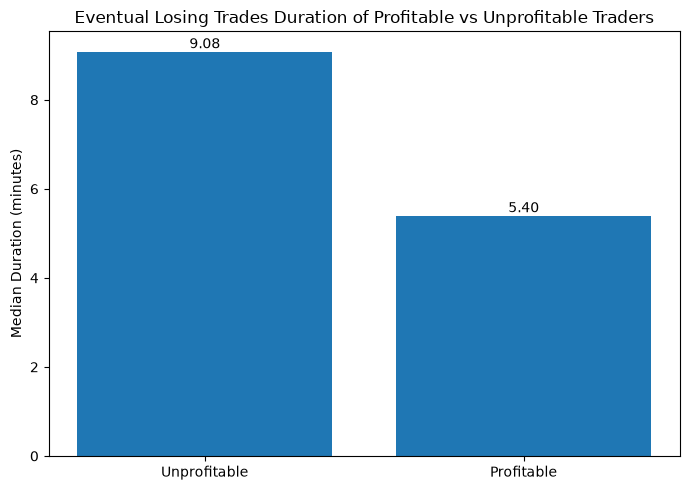

In [ ]:
trade_duration_values = (
    duration_plot_summary[
        "median_losing_trade_duration_minutes"
    ]
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    trade_duration_values.index,
    trade_duration_values.values,
)

plt.ylabel(
    "Median Duration (minutes)"
)

plt.title(
    "Eventual Losing Trades Duration of Profitable vs Unprofitable Traders"
)

for bar, value in zip(
    bars,
    trade_duration_values.values,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

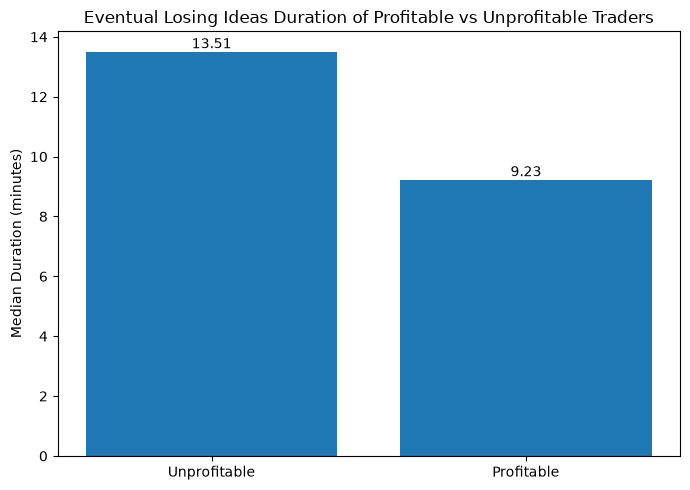

In [ ]:
idea_duration_values = (
    duration_plot_summary[
        "median_losing_idea_duration_minutes"
    ]
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    idea_duration_values.index,
    idea_duration_values.values,
)

plt.ylabel(
    "Median Duration (minutes)"
)

plt.title(
    "Eventual Losing Ideas Duration of Profitable vs Unprofitable Traders"
)

for bar, value in zip(
    bars,
    idea_duration_values.values,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

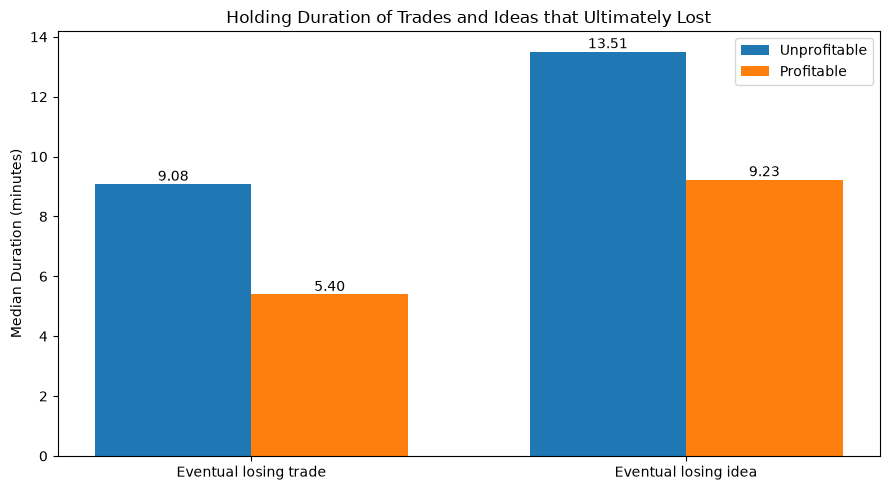

In [ ]:
combined_duration_plot = (
    duration_plot_summary
    .rename(
        columns={
            "median_losing_trade_duration_minutes":
                "Eventual losing trade",
            "median_losing_idea_duration_minutes":
                "Eventual losing idea",
        }
    )
    .T
)

x_positions = np.arange(
    len(combined_duration_plot.index)
)

bar_width = 0.36

plt.figure(figsize=(9, 5))

unprofitable_bars = plt.bar(
    x_positions - bar_width / 2,
    combined_duration_plot[
        "Unprofitable"
    ],
    width=bar_width,
    label="Unprofitable",
)

profitable_bars = plt.bar(
    x_positions + bar_width / 2,
    combined_duration_plot[
        "Profitable"
    ],
    width=bar_width,
    label="Profitable",
)

plt.xticks(
    x_positions,
    combined_duration_plot.index,
)

plt.ylabel("Median Duration (minutes)")

plt.title(
    "Holding Duration of Trades and Ideas that Ultimately Lost"
)

for bars in [
    unprofitable_bars,
    profitable_bars,
]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom",
        )

plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd


def run_duration_mann_whitney_test(
    data: pd.DataFrame,
    feature: str,
    feature_label: str,
) -> dict:
    """Runs a Mann–Whitney U test for one holding-duration feature.

    Args:
        data: Account-campaign feature table containing profitability labels.
        feature: Numeric duration feature to compare.
        feature_label: Readable feature name for reporting.

    Returns:
        Dictionary containing medians, test statistics, p-value, and
        rank-biserial effect size.
    """
    profitable_values = (
        data.loc[
            data["profitable"],
            feature,
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    unprofitable_values = (
        data.loc[
            ~data["profitable"],
            feature,
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    u_statistic, p_value = stats.mannwhitneyu(
        profitable_values,
        unprofitable_values,
        alternative="two-sided",
    )

    rank_biserial = (
        2 * u_statistic
        / (
            len(profitable_values)
            * len(unprofitable_values)
        )
        - 1
    )

    return {
        "feature": feature_label,
        "profitable_n": len(profitable_values),
        "unprofitable_n": len(unprofitable_values),
        "profitable_median_minutes": profitable_values.median(),
        "unprofitable_median_minutes": unprofitable_values.median(),
        "median_difference_minutes": (
            profitable_values.median()
            - unprofitable_values.median()
        ),
        "u_statistic": u_statistic,
        "p_value": p_value,
        "rank_biserial": rank_biserial,
    }

In [ ]:
all_traders = account_campaign_features.copy()

duration_test_results = pd.DataFrame(
    [
        run_duration_mann_whitney_test(
            data=all_traders,
            feature="median_losing_trade_duration_minutes",
            feature_label="Eventual losing-trade duration",
        ),
        run_duration_mann_whitney_test(
            data=all_traders,
            feature="median_losing_idea_duration_minutes",
            feature_label="Eventual losing-idea duration",
        ),
    ]
)

number_of_tests = len(duration_test_results)
bonferroni_alpha = 0.05 / number_of_tests

duration_test_results["bonferroni_alpha"] = (
    bonferroni_alpha
)

duration_test_results["reject_null"] = (
    duration_test_results["p_value"]
    < bonferroni_alpha
)

duration_test_results_display = (
    duration_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median_minutes",
            "unprofitable_median_minutes",
            "median_difference_minutes",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

duration_test_results_display[
    "profitable_median_minutes"
] = duration_test_results_display[
    "profitable_median_minutes"
].round(2)

duration_test_results_display[
    "unprofitable_median_minutes"
] = duration_test_results_display[
    "unprofitable_median_minutes"
].round(2)

duration_test_results_display[
    "median_difference_minutes"
] = duration_test_results_display[
    "median_difference_minutes"
].round(2)

duration_test_results_display[
    "u_statistic"
] = duration_test_results_display[
    "u_statistic"
].round(0)

duration_test_results_display[
    "p_value"
] = duration_test_results_display[
    "p_value"
].map(
    lambda value: f"{value:.3e}"
)

duration_test_results_display[
    "bonferroni_alpha"
] = duration_test_results_display[
    "bonferroni_alpha"
].round(3)

duration_test_results_display[
    "rank_biserial"
] = duration_test_results_display[
    "rank_biserial"
].round(3)

duration_test_results_display = (
    duration_test_results_display
    .set_index("feature")
    .T
)

duration_test_results_display.index.name = None
duration_test_results_display.columns.name = None

display(duration_test_results_display)

,Eventual losing-trade duration,Eventual losing-idea duration
profitable_n,1615,1372
unprofitable_n,5462,5462
profitable_median_minutes,5.4,9.23
unprofitable_median_minutes,9.08,13.51
median_difference_minutes,-3.68,-4.27
u_statistic,3585042.0,3173822.0
p_value,2.501e-30,1.753e-18
bonferroni_alpha,0.025,0.025
rank_biserial,-0.187,-0.153
reject_null,True,True


In [ ]:
for _, row in duration_test_results.iterrows():
    decision = (
        "Reject the null hypothesis"
        if row["reject_null"]
        else "Fail to reject the null hypothesis"
    )

    print(row["feature"])
    print(
        f"Profitable median: "
        f"{row['profitable_median_minutes']:.2f} minutes"
    )
    print(
        f"Unprofitable median: "
        f"{row['unprofitable_median_minutes']:.2f} minutes"
    )
    print(
        f"U = {row['u_statistic']:.0f}, "
        f"p = {row['p_value']:.3e}, "
        f"rank-biserial = {row['rank_biserial']:.3f}"
    )
    print(
        f"{decision} at the Bonferroni-adjusted "
        f"alpha of {bonferroni_alpha:.3f}."
    )
    print()

Eventual losing-trade duration
Profitable median: 5.40 minutes
Unprofitable median: 9.08 minutes
U = 3585042, p = 2.501e-30, rank-biserial = -0.187
Reject the null hypothesis at the Bonferroni-adjusted alpha of 0.025.

Eventual losing-idea duration
Profitable median: 9.23 minutes
Unprofitable median: 13.51 minutes
U = 3173822, p = 1.753e-18, rank-biserial = -0.153
Reject the null hypothesis at the Bonferroni-adjusted alpha of 0.025.



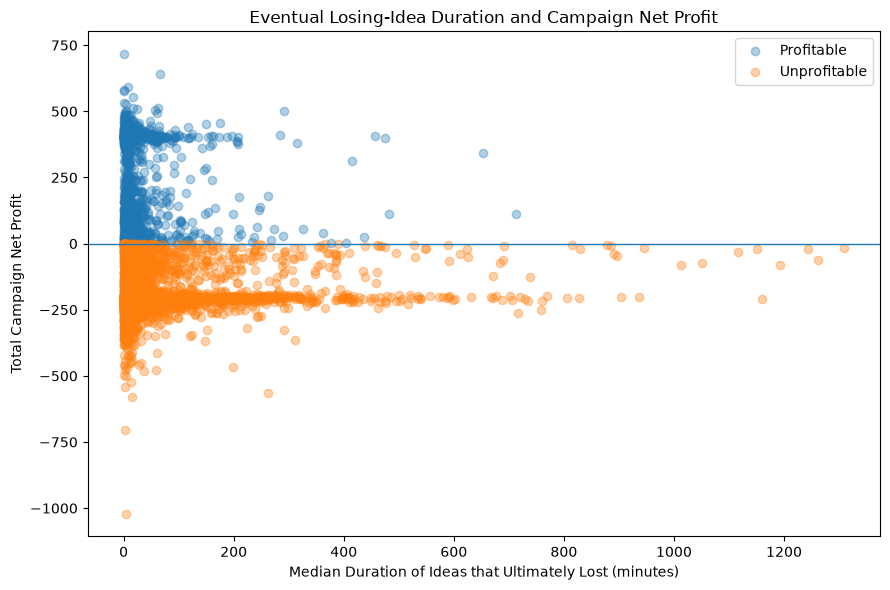

In [ ]:
plot_data = (
    account_campaign_features[
        [
            "median_losing_idea_duration_minutes",
            "total_net_profit",
            "profitability_group",
        ]
    ]
    .replace(
        [np.inf, -np.inf],
        np.nan,
    )
    .dropna()
)

plt.figure(figsize=(9, 6))

for group_name, group_data in plot_data.groupby(
    "profitability_group"
):
    plt.scatter(
        group_data[
            "median_losing_idea_duration_minutes"
        ],
        group_data["total_net_profit"],
        alpha=0.35,
        label=group_name,
    )

plt.axhline(
    y=0,
    linewidth=1,
)

plt.xlabel(
    "Median Duration of Ideas that Ultimately Lost (minutes)"
)

plt.ylabel("Total Campaign Net Profit")

plt.title(
    "Eventual Losing-Idea Duration and Campaign Net Profit"
)

plt.legend()
plt.tight_layout()
plt.show()

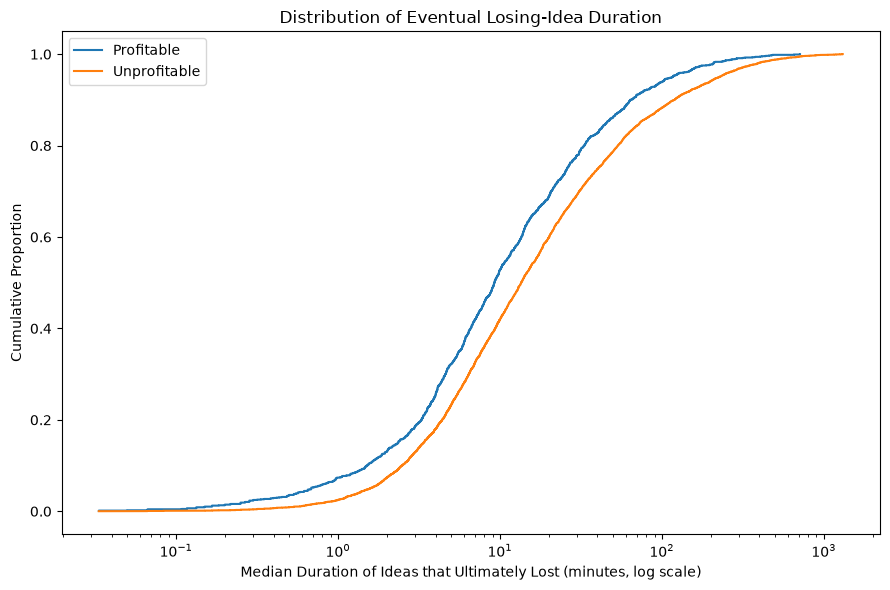

In [ ]:
plot_data = (
    account_campaign_features[
        [
            "median_losing_idea_duration_minutes",
            "profitability_group",
        ]
    ]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)

plt.figure(figsize=(9, 6))

for group_name, group_data in plot_data.groupby(
    "profitability_group"
):
    values = np.sort(
        group_data[
            "median_losing_idea_duration_minutes"
        ]
    )

    cumulative_probability = (
        np.arange(1, len(values) + 1)
        / len(values)
    )

    plt.step(
        values,
        cumulative_probability,
        where="post",
        label=group_name,
    )

plt.xscale("log")

plt.xlabel(
    "Median Duration of Ideas that Ultimately Lost (minutes, log scale)"
)
plt.ylabel("Cumulative Proportion")
plt.title(
    "Distribution of Eventual Losing-Idea Duration"
)
plt.legend()
plt.tight_layout()
plt.show()

## Trading intensity

In [ ]:
intensity_plot_summary = (
    all_trader_features
    .groupby("profitability_group")
    .agg(
        median_trades_per_active_hour=(
            "trades_per_active_hour",
            "median",
        ),
        median_ideas_per_active_hour=(
            "ideas_per_active_hour",
            "median",
        ),
    )
    .reindex(
        [
            "Unprofitable",
            "Profitable",
        ]
    )
)

display(intensity_plot_summary.round(2))

,median_trades_per_active_hour,median_ideas_per_active_hour
profitability_group,,
Unprofitable,2.28,1.77
Profitable,1.32,1.02


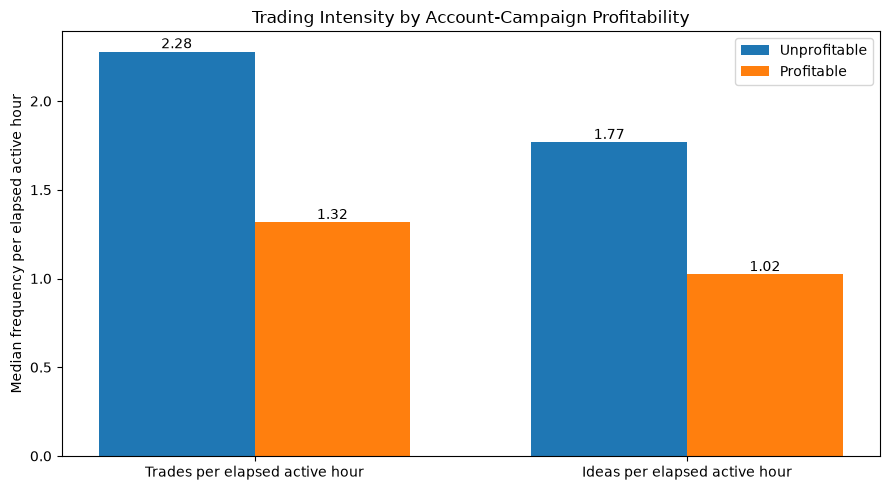

In [ ]:
combined_intensity_plot = (
    intensity_plot_summary
    .rename(
        columns={
            "median_trades_per_active_hour":
                "Trades per elapsed active hour",
            "median_ideas_per_active_hour":
                "Ideas per elapsed active hour",
        }
    )
    .T
)

x_positions = np.arange(
    len(combined_intensity_plot.index)
)

bar_width = 0.36

plt.figure(figsize=(9, 5))

unprofitable_bars = plt.bar(
    x_positions - bar_width / 2,
    combined_intensity_plot[
        "Unprofitable"
    ],
    width=bar_width,
    label="Unprofitable",
)

profitable_bars = plt.bar(
    x_positions + bar_width / 2,
    combined_intensity_plot[
        "Profitable"
    ],
    width=bar_width,
    label="Profitable",
)

plt.xticks(
    x_positions,
    combined_intensity_plot.index,
)

plt.ylabel("Median frequency per elapsed active hour")

plt.title(
    "Trading Intensity by Account-Campaign Profitability"
)

plt.legend()

for bars in [
    unprofitable_bars,
    profitable_bars,
]:
    for bar in bars:
        value = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.2f}",
            ha="center",
            va="bottom",
        )

plt.tight_layout()
plt.show()

In [ ]:
intensity_test_results = (
    activity_test_results.loc[
        activity_test_results[
            "feature"
        ].isin(
            [
                "trades_per_active_hour",
                "ideas_per_active_hour",
            ]
        )
    ]
    .copy()
)

In [ ]:
intensity_bonferroni_alpha = 0.05 / 2

In [ ]:
intensity_test_results[
    "bonferroni_alpha"
] = intensity_bonferroni_alpha

intensity_test_results[
    "reject_null"
] = (
    intensity_test_results[
        "p_value"
    ]
    < intensity_bonferroni_alpha
)

In [ ]:
intensity_feature_labels = {
    "trades_per_active_hour":
        "Trades per elapsed active hour",
    "ideas_per_active_hour":
        "Ideas per elapsed active hour",
}

intensity_test_results[
    "feature"
] = (
    intensity_test_results[
        "feature"
    ]
    .map(intensity_feature_labels)
)

In [ ]:
intensity_test_results_display = (
    intensity_test_results[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "bonferroni_alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

In [ ]:
for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
]:
    intensity_test_results_display[
        column
    ] = (
        intensity_test_results_display[
            column
        ]
        .round(4)
    )

intensity_test_results_display[
    "u_statistic"
] = (
    intensity_test_results_display[
        "u_statistic"
    ]
    .round(0)
)

intensity_test_results_display[
    "p_value"
] = (
    intensity_test_results_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

intensity_test_results_display[
    "bonferroni_alpha"
] = (
    intensity_test_results_display[
        "bonferroni_alpha"
    ]
    .round(3)
)

intensity_test_results_display[
    "rank_biserial"
] = (
    intensity_test_results_display[
        "rank_biserial"
    ]
    .round(3)
)

intensity_test_results_display = (
    intensity_test_results_display
    .set_index("feature")
    .T
)

intensity_test_results_display.index.name = None
intensity_test_results_display.columns.name = None

display(intensity_test_results_display)

,Trades per elapsed active hour,Ideas per elapsed active hour
profitable_n,2703,2703
unprofitable_n,5462,5462
profitable_median,1.3168,1.0234
unprofitable_median,2.279,1.7678
median_difference,-0.9623,-0.7444
u_statistic,5974921.0,5901162.0
p_value,9.263e-45,2.194e-49
bonferroni_alpha,0.025,0.025
rank_biserial,-0.191,-0.201
reject_null,True,True


## Direction switching waiting time

In [ ]:
direction_wait_plot_summary = (
    all_trader_direction_features
    .groupby("profitability_group")
    .agg(
        median_direction_switch_gap_minutes=(
            "median_direction_switch_gap_minutes",
            "median",
        ),
    )
    .reindex(
        [
            "Unprofitable",
            "Profitable",
        ]
    )
)

display(direction_wait_plot_summary.round(2))

,median_direction_switch_gap_minutes
profitability_group,
Unprofitable,3.82
Profitable,6.60


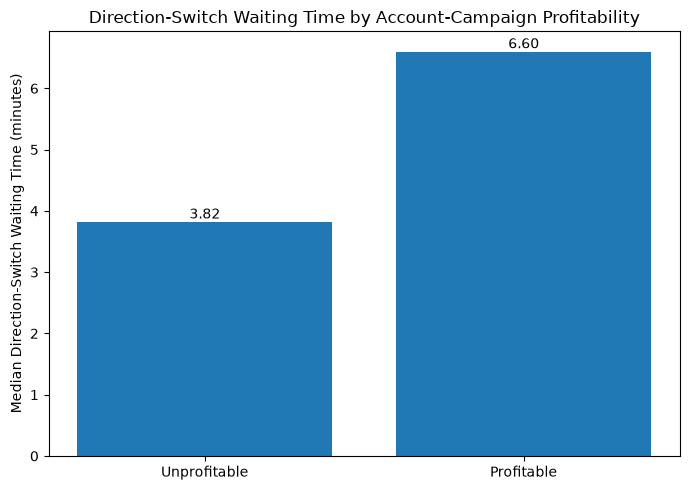

In [ ]:
direction_wait_values = (
    direction_wait_plot_summary[
        "median_direction_switch_gap_minutes"
    ]
)

plt.figure(figsize=(7, 5))

bars = plt.bar(
    direction_wait_values.index,
    direction_wait_values.values,
)

plt.ylabel(
    "Median Direction-Switch Waiting Time (minutes)"
)

plt.title(
    "Direction-Switch Waiting Time by Account-Campaign Profitability"
)

for bar, value in zip(
    bars,
    direction_wait_values.values,
):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value,
        f"{value:.2f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

In [ ]:
direction_wait_test_result = (
    direction_switch_test_results.loc[
        direction_switch_test_results[
            "feature"
        ] == "median_direction_switch_gap_minutes"
    ]
    .copy()
)

In [ ]:
direction_wait_alpha = 0.05

direction_wait_test_result[
    "alpha"
] = direction_wait_alpha

direction_wait_test_result[
    "reject_null"
] = (
    direction_wait_test_result[
        "p_value"
    ]
    < direction_wait_alpha
)

In [ ]:
direction_wait_test_display = (
    direction_wait_test_result[
        [
            "feature",
            "profitable_n",
            "unprofitable_n",
            "profitable_median",
            "unprofitable_median",
            "median_difference",
            "u_statistic",
            "p_value",
            "alpha",
            "rank_biserial",
            "reject_null",
        ]
    ]
    .copy()
)

In [ ]:
for column in [
    "profitable_median",
    "unprofitable_median",
    "median_difference",
]:
    direction_wait_test_display[
        column
    ] = (
        direction_wait_test_display[
            column
        ]
        .round(2)
    )

direction_wait_test_display[
    "u_statistic"
] = (
    direction_wait_test_display[
        "u_statistic"
    ]
    .round(0)
)

direction_wait_test_display[
    "p_value"
] = (
    direction_wait_test_display[
        "p_value"
    ]
    .map(
        lambda value: f"{value:.3e}"
    )
)

direction_wait_test_display[
    "alpha"
] = (
    direction_wait_test_display[
        "alpha"
    ]
    .round(2)
)

direction_wait_test_display[
    "rank_biserial"
] = (
    direction_wait_test_display[
        "rank_biserial"
    ]
    .round(3)
)

direction_wait_test_display = (
    direction_wait_test_display
    .set_index("feature")
    .T
)

direction_wait_test_display.index.name = None
direction_wait_test_display.columns.name = None

display(direction_wait_test_display)

,median_direction_switch_gap_minutes
profitable_n,1671
unprofitable_n,2846
profitable_median,6.6
unprofitable_median,3.82
median_difference,2.78
u_statistic,2709388.0
p_value,4.668e-15
alpha,0.05
rank_biserial,0.139
reject_null,True
